# Encoder-Decoder (Seq2Seq) Forecasting: LSTM and Transformer

**Architecture:** True encoder-decoder with teacher forcing during training, autoregressive generation during inference.

**Models:** LSTM Seq2Seq + Transformer Seq2Seq

**Key difference from recursive:** The decoder is a separate neural network trained to generate sequences. During training it sees real targets (teacher forcing). During inference it uses its own predictions. The recursive approach used the same single-step model in a loop. Here the decoder is architecturally designed for sequential generation.

**Same setup:** 30 features, same split, same scaling, same Optuna, same seed, same evaluation at all 12 steps.


In [1]:
!pip install optuna -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, random, time, warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.8 MB/s eta 0:00:00
Device: cuda


## 1. Data Pipeline (identical to all other notebooks)


In [2]:
FILENAME = '/content/Final2026_with_ENTSOE.csv'

try:
    df = pd.read_csv(FILENAME, sep=',')
    if len(df.columns) == 1: df = pd.read_csv(FILENAME, sep=';')
except: df = pd.read_csv(FILENAME)

df = df.rename(columns={
    'Day time': 'DELIVERY_MTU', 'DAM price': 'DAM_MCP',
    'IDA1': 'MCP', 'IDA2': 'MCP_IDA2', 'IDA3': 'MCP_IDA3',
    'BM price': 'BM_IMBALANCE_PRICE', 'BMmDAM price': 'BMmDAMMCP',
})
df['DELIVERY_MTU'] = pd.to_datetime(df['DELIVERY_MTU'])
df = df.sort_values('DELIVERY_MTU').reset_index(drop=True)

df['hour'] = df['DELIVERY_MTU'].dt.hour
df['minute'] = df['DELIVERY_MTU'].dt.minute / 60.0
df['dayofweek'] = df['DELIVERY_MTU'].dt.dayofweek
df['ida3_available'] = df['MCP_IDA3'].notna().astype(float)
df['MCP_IDA3'] = df['MCP_IDA3'].fillna(0.0)
df['MCP_IDA2'] = df['MCP_IDA2'].ffill().bfill().fillna(0.0)
df['MCP'] = df['MCP'].ffill().bfill().fillna(df['MCP_IDA2'])
df['DAM_MCP'] = df['DAM_MCP'].ffill().bfill()
df['BMmDAMMCP'] = df['BMmDAMMCP'].ffill().bfill().fillna(0.0)
df['BM_IMBALANCE_PRICE'] = df['BM_IMBALANCE_PRICE'].ffill().bfill().fillna(df['BM_IMBALANCE_PRICE'].median())
df['IDA_target'] = np.where(df['ida3_available'] == 1, df['MCP_IDA3'], df['MCP_IDA2'])
df['ISP2_RES'] = df['ISP2_RES'].ffill().bfill().fillna(df['ISP1_RES'])
df['ISP2_Load'] = df['ISP2_Load'].ffill().bfill().fillna(df['ISP1_Load'])

df['DA_RES'] = df['Wind_DA_forecast'] + df['Solar_DA_forecast']
is_ida3 = df['hour'] >= 12
df['latest_RES'] = np.where(is_ida3, df['ISP3_RES'], df['ISP2_RES'])
df['latest_Load'] = np.where(is_ida3, df['ISP3_Load'], df['ISP2_Load'])
df['latest_RES_revision'] = df['latest_RES'] - df['DA_RES']
df['latest_Load_revision'] = df['latest_Load'] - df['SystemLoad_DA_forecast']
df['latest_net_load'] = df['latest_Load'] - df['latest_RES']
df['DA_net_load'] = df['SystemLoad_DA_forecast'] - df['DA_RES']
df['latest_net_load_revision'] = df['latest_net_load'] - df['DA_net_load']
df['RES_revision_ISP2_to_ISP3'] = np.where(is_ida3, df['ISP3_RES'] - df['ISP2_RES'], 0.0)
df['Load_revision_ISP2_to_ISP3'] = np.where(is_ida3, df['ISP3_Load'] - df['ISP2_Load'], 0.0)

df['bm_roll_mean_4'] = df['BM_IMBALANCE_PRICE'].rolling(4, min_periods=1).mean()
df['bm_roll_std_4'] = df['BM_IMBALANCE_PRICE'].rolling(4, min_periods=1).std().fillna(0)
df['bm_roll_mean_12'] = df['BM_IMBALANCE_PRICE'].rolling(12, min_periods=1).mean()
df['ida_momentum'] = df['MCP_IDA2'].diff(4).fillna(0)
df['mcp_momentum'] = df['MCP'].diff(4).fillna(0)
df['bm_momentum'] = df['BM_IMBALANCE_PRICE'].diff(4).fillna(0)
df['bm_ida_spread'] = df['BM_IMBALANCE_PRICE'] - df['MCP_IDA2']
df['ida_roll_std_4'] = df['MCP_IDA2'].rolling(4, min_periods=1).std().fillna(0)

# 12-step targets
PRED_STEPS = 12
for s in range(1, PRED_STEPS + 1):
    df[f'IDA_target_step{s}'] = df['IDA_target'].shift(-s)
    df[f'ida3_at_step{s}'] = (df['hour'].shift(-s) >= 12).astype(float)

df = df.dropna(subset=[f'IDA_target_step{s}' for s in range(1, PRED_STEPS + 1)]).reset_index(drop=True)
df = df[df['DELIVERY_MTU'] >= '2025-10-02'].copy().reset_index(drop=True)
df = df[df['DELIVERY_MTU'] <= '2026-01-18 23:45:00'].copy().reset_index(drop=True)

# Same 30 features as all other notebooks
FEATURES = [
    'MCP', 'MCP_IDA2', 'DAM_MCP',
    'BM_IMBALANCE_PRICE', 'bm_roll_mean_4', 'bm_roll_std_4', 'bm_roll_mean_12', 'bm_ida_spread',
    'ida_momentum', 'mcp_momentum', 'bm_momentum', 'ida_roll_std_4',
    'SystemLoad_DA_forecast', 'Wind_DA_forecast', 'Solar_DA_forecast',
    'ida3_available', 'ida3_at_step4', 'ida3_at_step8', 'ida3_at_step12',
    'hour', 'minute', 'dayofweek',
    'latest_RES', 'latest_Load',
    'latest_RES_revision', 'latest_Load_revision', 'latest_net_load_revision', 'latest_net_load',
    'RES_revision_ISP2_to_ISP3', 'Load_revision_ISP2_to_ISP3',
]
TARGETS = [f'IDA_target_step{s}' for s in range(1, PRED_STEPS + 1)]

BATCH = 64; TRAIN_RATIO = 0.8
N_FEAT = len(FEATURES)
split_idx = int(len(df) * TRAIN_RATIO)

df[FEATURES] = df[FEATURES].ffill().bfill().fillna(0)

scaler_X = MinMaxScaler()
data_X = df[FEATURES].values.astype(np.float32)
scaler_X.fit(data_X[:split_idx])
data_X_sc = scaler_X.transform(data_X)

scaler_y = MinMaxScaler()
all_tgt = df[TARGETS].values.astype(np.float32)
# Fit scaler on all target values reshaped
scaler_y.fit(all_tgt[:split_idx].reshape(-1, 1))
tgt_sc = np.zeros_like(all_tgt)
for h in range(PRED_STEPS):
    tgt_sc[:, h] = scaler_y.transform(all_tgt[:, h].reshape(-1, 1)).flatten()

print(f"Dataset: {df.shape}, Features: {N_FEAT}, Targets: {PRED_STEPS} steps")
print(f"Train: {split_idx}, Test: {len(df)-split_idx}")



Dataset: (10464, 63), Features: 30, Targets: 12 steps
Train: 8371, Test: 2093


## 2. Seq2Seq Dataset

The dataset returns three tensors per sample:
- **Encoder input:** lookback window (lb, 30 features)
- **Decoder input:** shifted targets [0, y1, ..., y11] for teacher forcing
- **Decoder target:** actual targets [y1, y2, ..., y12]


In [3]:
class Seq2SeqDataset(Dataset):
    """Dataset for encoder-decoder models.
    Returns: (encoder_input, decoder_input, decoder_target)
    - encoder_input: lookback window (lb, n_feat)
    - decoder_input: shifted target sequence [0, y1, y2, ..., y11] (12, 1)
    - decoder_target: target sequence [y1, y2, ..., y12] (12,)
    """
    def __init__(self, X, y, lb):
        self.X, self.y, self.lb = X, y, lb

    def __len__(self):
        return len(self.X) - self.lb

    def __getitem__(self, i):
        enc_input = torch.tensor(self.X[i:i+self.lb], dtype=torch.float32)
        target = torch.tensor(self.y[i+self.lb], dtype=torch.float32)  # (12,)

        # Decoder input: start token (0) + first 11 targets (teacher forcing)
        dec_input = torch.zeros(PRED_STEPS, 1, dtype=torch.float32)
        dec_input[1:, 0] = target[:-1]  # shift right: [0, y1, y2, ..., y11]

        return enc_input, dec_input, target

print("Seq2SeqDataset defined")
print("  Encoder input: (lookback, 30 features)")
print("  Decoder input: (12, 1) = [start_token, y1, ..., y11]")
print("  Decoder target: (12,) = [y1, y2, ..., y12]")



Seq2SeqDataset defined
  Encoder input: (lookback, 30 features)
  Decoder input: (12, 1) = [start_token, y1, ..., y11]
  Decoder target: (12,) = [y1, y2, ..., y12]


## 3. LSTM Encoder-Decoder

**Encoder:** LSTM reads the lookback window, produces context (final hidden state).

**Decoder:** At each of 12 steps, receives (previous prediction + context), produces next value. During training: teacher forcing feeds real targets. During inference: uses own predictions.


In [4]:
class LSTMSeq2Seq(nn.Module):
    """LSTM Encoder-Decoder with teacher forcing for 12-step forecasting."""

    def __init__(self, n_feat, enc_hidden, dec_hidden, enc_layers=1, dec_layers=1, dropout=0.2):
        super().__init__()
        self.dec_hidden = dec_hidden
        self.dec_layers = dec_layers
        self.pred_steps = PRED_STEPS

        # Encoder: reads lookback window
        self.encoder = nn.LSTM(n_feat, enc_hidden, enc_layers, batch_first=True,
                               dropout=dropout if enc_layers > 1 else 0.0)

        # Bridge: project encoder hidden to decoder hidden (if sizes differ)
        self.bridge_h = nn.Linear(enc_hidden, dec_hidden)
        self.bridge_c = nn.Linear(enc_hidden, dec_hidden)

        # Decoder: generates output step by step
        # Input: previous prediction (1) + encoder context projected (dec_hidden)
        self.decoder = nn.LSTM(1 + dec_hidden, dec_hidden, dec_layers, batch_first=True,
                               dropout=dropout if dec_layers > 1 else 0.0)

        # Context projection from encoder final hidden
        self.context_proj = nn.Linear(enc_hidden, dec_hidden)

        # Output projection: decoder hidden -> single value
        self.fc_out = nn.Linear(dec_hidden, 1)

    def forward(self, enc_input, dec_input=None, teacher_forcing_ratio=0.5):
        batch_size = enc_input.size(0)

        # Encode
        _, (h_enc, c_enc) = self.encoder(enc_input)
        # Use last layer hidden state
        h_last = h_enc[-1]  # (batch, enc_hidden)
        context = self.context_proj(h_last)  # (batch, dec_hidden)

        # Bridge encoder hidden to decoder hidden
        h_dec = self.bridge_h(h_last).unsqueeze(0).repeat(self.dec_layers, 1, 1)
        c_dec = self.bridge_c(c_enc[-1]).unsqueeze(0).repeat(self.dec_layers, 1, 1)

        # Decode step by step
        outputs = []
        prev_pred = torch.zeros(batch_size, 1, dtype=enc_input.dtype, device=enc_input.device)

        for t in range(self.pred_steps):
            # Decoder input: [previous_prediction, context]
            dec_step_input = torch.cat([prev_pred, context], dim=-1).unsqueeze(1)  # (batch, 1, 1+dec_hidden)
            dec_out, (h_dec, c_dec) = self.decoder(dec_step_input, (h_dec, c_dec))
            pred = self.fc_out(dec_out.squeeze(1))  # (batch, 1)
            outputs.append(pred)

            # Teacher forcing decision
            if dec_input is not None and random.random() < teacher_forcing_ratio:
                prev_pred = dec_input[:, t, :]  # use real target
            else:
                prev_pred = pred.detach()  # use own prediction

        return torch.cat(outputs, dim=-1)  # (batch, 12)

print("LSTMSeq2Seq defined")
print("  Encoder: LSTM reads lookback window")
print("  Decoder: LSTM generates 12 steps with teacher forcing")



LSTMSeq2Seq defined
  Encoder: LSTM reads lookback window
  Decoder: LSTM generates 12 steps with teacher forcing


## 4. Transformer Encoder-Decoder

**Encoder:** TransformerEncoder with positional encoding (same as encoder-only version).

**Decoder:** TransformerDecoder with causal mask (can only see past) + cross-attention to encoder memory. During training: parallel computation with teacher forcing. During inference: autoregressive step-by-step generation.


In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerSeq2Seq(nn.Module):
    """Transformer Encoder-Decoder with teacher forcing for 12-step forecasting."""

    def __init__(self, n_feat, d_model, nhead, enc_layers, dec_layers, dim_ff, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.pred_steps = PRED_STEPS

        # Encoder
        self.enc_input_proj = nn.Linear(n_feat, d_model)
        self.enc_pos = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=enc_layers)

        # Decoder
        self.dec_input_proj = nn.Linear(1, d_model)  # project scalar target to d_model
        self.dec_pos = PositionalEncoding(d_model)
        dec_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout, batch_first=True, activation='gelu')
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=dec_layers)

        # Output
        self.fc_out = nn.Linear(d_model, 1)

    def _generate_causal_mask(self, sz):
        """Upper triangular mask so decoder can only see past positions."""
        mask = torch.triu(torch.ones(sz, sz), diagonal=1).bool()
        return mask.to(next(self.parameters()).device)

    def forward(self, enc_input, dec_input=None, teacher_forcing_ratio=0.5):
        batch_size = enc_input.size(0)

        # Encode lookback window
        enc_proj = self.enc_pos(self.enc_input_proj(enc_input))
        memory = self.encoder(enc_proj)  # (batch, lookback, d_model)

        if dec_input is not None and random.random() < teacher_forcing_ratio:
            # Full teacher forcing: run decoder in parallel with real targets
            dec_proj = self.dec_pos(self.dec_input_proj(dec_input))  # (batch, 12, d_model)
            causal_mask = self._generate_causal_mask(self.pred_steps)
            dec_out = self.decoder(dec_proj, memory, tgt_mask=causal_mask)
            output = self.fc_out(dec_out).squeeze(-1)  # (batch, 12)
        else:
            # Autoregressive: generate step by step
            outputs = []
            prev = torch.zeros(batch_size, 1, 1, dtype=enc_input.dtype, device=enc_input.device)
            for t in range(self.pred_steps):
                dec_proj = self.dec_pos(self.dec_input_proj(prev))
                causal_mask = self._generate_causal_mask(prev.size(1))
                dec_out = self.decoder(dec_proj, memory, tgt_mask=causal_mask)
                pred = self.fc_out(dec_out[:, -1:, :])  # take last position
                outputs.append(pred.squeeze(-1))
                prev = torch.cat([prev, pred], dim=1)  # append prediction
            output = torch.cat(outputs, dim=-1)  # (batch, 12)

        return output

print("TransformerSeq2Seq defined")
print("  Encoder: TransformerEncoder with positional encoding")
print("  Decoder: TransformerDecoder with causal mask + cross-attention")



TransformerSeq2Seq defined
  Encoder: TransformerEncoder with positional encoding
  Decoder: TransformerDecoder with causal mask + cross-attention


## 5. Training with Teacher Forcing Annealing

Teacher forcing ratio starts at 1.0 (always use real targets) and decreases to 0.1 over training. This helps the decoder learn stable generation while gradually exposing it to its own predictions. Evaluation always uses 0.0 (fully autoregressive).


In [6]:
def train_s2s(model, ld_tr, ld_te, epochs, lr, tf_start=1.0, tf_end=0.1, label=""):
    """Train encoder-decoder with teacher forcing annealing."""
    model = model.to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val = float('inf'); best_state = None

    for ep in range(1, epochs+1):
        # Anneal teacher forcing: start high, decrease over training
        tf_ratio = tf_start - (tf_start - tf_end) * (ep - 1) / max(epochs - 1, 1)

        model.train(); tl = 0
        for enc_x, dec_x, tgt in ld_tr:
            enc_x, dec_x, tgt = enc_x.to(device), dec_x.to(device), tgt.to(device)
            opt.zero_grad()
            pred = model(enc_x, dec_x, teacher_forcing_ratio=tf_ratio)
            loss = crit(pred, tgt)
            loss.backward(); opt.step()
            tl += loss.item() * enc_x.size(0)
        tl /= len(ld_tr.dataset)

        model.eval(); vl = 0
        with torch.no_grad():
            for enc_x, dec_x, tgt in ld_te:
                enc_x, dec_x, tgt = enc_x.to(device), dec_x.to(device), tgt.to(device)
                pred = model(enc_x, teacher_forcing_ratio=0.0)  # no teacher forcing at eval
                vl += crit(pred, tgt).item() * enc_x.size(0)
        vl /= len(ld_te.dataset)
        sched.step()

        if vl < best_val:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if ep % 30 == 0 or ep == 1:
            print(f"  [{label}] {ep:3d}/{epochs} | train: {tl:.6f} | val: {vl:.6f} | tf: {tf_ratio:.2f}")

    model.load_state_dict(best_state)
    print(f"  [{label}] Best: {best_val:.6f}")
    return best_val

def compute_metrics(y_true, y_pred, y_naive):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_naive = mean_absolute_error(y_true, y_naive)
    fsi  = 1 - mae / mae_naive
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'FSI': fsi}

print("Training function with teacher forcing annealing ready")
print("  TF ratio: 1.0 (start) -> 0.1 (end)")



Training function with teacher forcing annealing ready
  TF ratio: 1.0 (start) -> 0.1 (end)


## 6. Optuna: LSTM Seq2Seq (30 trials)


In [7]:
SEARCH_EPOCHS = 50

def lstm_s2s_objective(trial):
    lb = trial.suggest_categorical('lookback', [24, 48])
    enc_hidden = trial.suggest_categorical('enc_hidden', [64, 128])
    dec_hidden = trial.suggest_categorical('dec_hidden', [64, 128])
    enc_layers = trial.suggest_int('enc_layers', 1, 2)
    dec_layers = trial.suggest_int('dec_layers', 1, 2)
    lr = trial.suggest_float('lr', 5e-4, 3e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3, step=0.1)

    tr = Seq2SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
    te = Seq2SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
    ld_tr = DataLoader(tr, batch_size=BATCH, shuffle=True)
    ld_te = DataLoader(te, batch_size=BATCH, shuffle=False)

    torch.manual_seed(SEED)
    model = LSTMSeq2Seq(N_FEAT, enc_hidden, dec_hidden, enc_layers, dec_layers, dropout).to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val = float('inf')
    for ep in range(1, SEARCH_EPOCHS + 1):
        tf_ratio = 1.0 - 0.9 * (ep - 1) / max(SEARCH_EPOCHS - 1, 1)
        model.train()
        for enc_x, dec_x, tgt in ld_tr:
            enc_x, dec_x, tgt = enc_x.to(device), dec_x.to(device), tgt.to(device)
            opt.zero_grad()
            loss = crit(model(enc_x, dec_x, tf_ratio), tgt)
            loss.backward(); opt.step()
        model.eval(); vl = 0
        with torch.no_grad():
            for enc_x, dec_x, tgt in ld_te:
                enc_x, tgt = enc_x.to(device), tgt.to(device)
                vl += crit(model(enc_x, teacher_forcing_ratio=0.0), tgt).item() * enc_x.size(0)
        vl /= len(ld_te.dataset)
        if vl < best_val: best_val = vl
        trial.report(vl, ep)
        if trial.should_prune(): raise optuna.TrialPruned()
    return best_val

print("Running LSTM Seq2Seq Optuna (30 trials)...")
lstm_study = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED))
lstm_study.optimize(lstm_s2s_objective, n_trials=30, show_progress_bar=True)
bp_lstm = lstm_study.best_trial.params
print(f"LSTM Seq2Seq best: {bp_lstm}, val_loss={lstm_study.best_trial.value:.6f}")



Running LSTM Seq2Seq Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

LSTM Seq2Seq best: {'lookback': 48, 'enc_hidden': 64, 'dec_hidden': 128, 'enc_layers': 2, 'dec_layers': 2, 'lr': 0.002008518824487966, 'dropout': 0.3}, val_loss=0.028952


## 7. Optuna: Transformer Seq2Seq (30 trials)


In [8]:
def tf_s2s_objective(trial):
    lb = trial.suggest_categorical('lookback', [24, 48])
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4])
    enc_layers = trial.suggest_int('enc_layers', 1, 3)
    dec_layers = trial.suggest_int('dec_layers', 1, 2)
    dim_ff = trial.suggest_categorical('dim_ff', [64, 128, 256])
    lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3, step=0.1)

    if d_model % nhead != 0:
        return float('inf')

    tr = Seq2SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
    te = Seq2SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
    ld_tr = DataLoader(tr, batch_size=BATCH, shuffle=True)
    ld_te = DataLoader(te, batch_size=BATCH, shuffle=False)

    torch.manual_seed(SEED)
    model = TransformerSeq2Seq(N_FEAT, d_model, nhead, enc_layers, dec_layers, dim_ff, dropout).to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val = float('inf')
    for ep in range(1, SEARCH_EPOCHS + 1):
        tf_ratio = 1.0 - 0.9 * (ep - 1) / max(SEARCH_EPOCHS - 1, 1)
        model.train()
        for enc_x, dec_x, tgt in ld_tr:
            enc_x, dec_x, tgt = enc_x.to(device), dec_x.to(device), tgt.to(device)
            opt.zero_grad()
            loss = crit(model(enc_x, dec_x, tf_ratio), tgt)
            loss.backward(); opt.step()
        model.eval(); vl = 0
        with torch.no_grad():
            for enc_x, dec_x, tgt in ld_te:
                enc_x, tgt = enc_x.to(device), tgt.to(device)
                vl += crit(model(enc_x, teacher_forcing_ratio=0.0), tgt).item() * enc_x.size(0)
        vl /= len(ld_te.dataset)
        if vl < best_val: best_val = vl
        trial.report(vl, ep)
        if trial.should_prune(): raise optuna.TrialPruned()
    return best_val

print("Running Transformer Seq2Seq Optuna (30 trials)...")
tf_study = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED))
tf_study.optimize(tf_s2s_objective, n_trials=30, show_progress_bar=True)
bp_tf = tf_study.best_trial.params
print(f"Transformer Seq2Seq best: {bp_tf}, val_loss={tf_study.best_trial.value:.6f}")



Running Transformer Seq2Seq Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

Transformer Seq2Seq best: {'lookback': 48, 'd_model': 64, 'nhead': 4, 'enc_layers': 1, 'dec_layers': 1, 'dim_ff': 64, 'lr': 0.0010765988801943755, 'dropout': 0.3}, val_loss=0.027118


## 8. Train Final Models (120 epochs)


In [9]:
EPOCHS = 120

# ── LSTM Seq2Seq ──
print("=" * 60)
print(f"LSTM Seq2Seq: {bp_lstm}")
lb = bp_lstm['lookback']
tr = Seq2SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
te = Seq2SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
torch.manual_seed(SEED)
model_lstm = LSTMSeq2Seq(N_FEAT, bp_lstm['enc_hidden'], bp_lstm['dec_hidden'],
    bp_lstm['enc_layers'], bp_lstm['dec_layers'], bp_lstm['dropout'])
train_s2s(model_lstm, DataLoader(tr, batch_size=BATCH, shuffle=True),
          DataLoader(te, batch_size=BATCH, shuffle=False), EPOCHS, bp_lstm['lr'], label="LSTM-S2S")

# ── Transformer Seq2Seq ──
print("=" * 60)
print(f"Transformer Seq2Seq: {bp_tf}")
lb = bp_tf['lookback']
tr = Seq2SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
te = Seq2SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
torch.manual_seed(SEED)
model_tf = TransformerSeq2Seq(N_FEAT, bp_tf['d_model'], bp_tf['nhead'],
    bp_tf['enc_layers'], bp_tf['dec_layers'], bp_tf['dim_ff'], bp_tf['dropout'])
train_s2s(model_tf, DataLoader(tr, batch_size=BATCH, shuffle=True),
          DataLoader(te, batch_size=BATCH, shuffle=False), EPOCHS, bp_tf['lr'], label="TF-S2S")

print("\nBoth encoder-decoder models trained.")



LSTM Seq2Seq: {'lookback': 48, 'enc_hidden': 64, 'dec_hidden': 128, 'enc_layers': 2, 'dec_layers': 2, 'lr': 0.002008518824487966, 'dropout': 0.3}
  [LSTM-S2S]   1/120 | train: 0.049198 | val: 0.109409 | tf: 1.00
  [LSTM-S2S]  30/120 | train: 0.023315 | val: 0.035574 | tf: 0.78
  [LSTM-S2S]  60/120 | train: 0.016566 | val: 0.039536 | tf: 0.55
  [LSTM-S2S]  90/120 | train: 0.013337 | val: 0.038404 | tf: 0.33
  [LSTM-S2S] 120/120 | train: 0.012389 | val: 0.038519 | tf: 0.10
  [LSTM-S2S] Best: 0.031675
Transformer Seq2Seq: {'lookback': 48, 'd_model': 64, 'nhead': 4, 'enc_layers': 1, 'dec_layers': 1, 'dim_ff': 64, 'lr': 0.0010765988801943755, 'dropout': 0.3}
  [TF-S2S]   1/120 | train: 0.105234 | val: 0.051800 | tf: 1.00
  [TF-S2S]  30/120 | train: 0.030309 | val: 0.045172 | tf: 0.78
  [TF-S2S]  60/120 | train: 0.025544 | val: 0.034699 | tf: 0.55
  [TF-S2S]  90/120 | train: 0.024294 | val: 0.033612 | tf: 0.33
  [TF-S2S] 120/120 | train: 0.024723 | val: 0.034239 | tf: 0.10
  [TF-S2S] Best: 0

## 9. Evaluate (Fully Autoregressive, No Teacher Forcing)


In [10]:
# Evaluate both models on test set (autoregressive, no teacher forcing)

def evaluate_s2s(model, data_sc, tgt_real, lookback, label):
    """Run autoregressive inference and inverse-transform predictions."""
    model.eval()
    ds = Seq2SeqDataset(data_sc[split_idx-lookback:], tgt_sc[split_idx-lookback:], lookback)
    ld = DataLoader(ds, batch_size=BATCH, shuffle=False)

    all_preds_sc = []
    all_tgts_sc = []
    with torch.no_grad():
        for enc_x, dec_x, tgt in ld:
            enc_x = enc_x.to(device)
            pred = model(enc_x, teacher_forcing_ratio=0.0)  # fully autoregressive
            all_preds_sc.append(pred.cpu().numpy())
            all_tgts_sc.append(tgt.numpy())

    preds_sc = np.concatenate(all_preds_sc, axis=0)  # (n_test, 12)
    tgts_sc = np.concatenate(all_tgts_sc, axis=0)

    # Inverse transform
    preds_real = np.zeros_like(preds_sc)
    tgts_real = np.zeros_like(tgts_sc)
    for h in range(PRED_STEPS):
        preds_real[:, h] = scaler_y.inverse_transform(preds_sc[:, h].reshape(-1, 1)).flatten()
        tgts_real[:, h] = scaler_y.inverse_transform(tgts_sc[:, h].reshape(-1, 1)).flatten()

    print(f"\n  {label} evaluated: {preds_real.shape[0]} samples")
    return preds_real, tgts_real

preds_lstm, acts_lstm = evaluate_s2s(model_lstm, data_X_sc, all_tgt, bp_lstm['lookback'], "LSTM-S2S")
preds_tf, acts_tf = evaluate_s2s(model_tf, data_X_sc, all_tgt, bp_tf['lookback'], "TF-S2S")

# Common length
n_test = min(len(preds_lstm), len(preds_tf))
preds_lstm = preds_lstm[-n_test:]
preds_tf = preds_tf[-n_test:]
acts = acts_lstm[-n_test:]  # actuals are the same
naive_vals = df['IDA_target'].values[split_idx:split_idx+n_test]

results = {'LSTM Seq2Seq': preds_lstm, 'Transformer Seq2Seq': preds_tf}
print(f"Test samples: {n_test}")




  LSTM-S2S evaluated: 2093 samples

  TF-S2S evaluated: 2093 samples
Test samples: 2093


## 10. Results: All 12 Steps


In [11]:
print("  ENCODER-DECODER (SEQ2SEQ) RESULTS - ALL 12 STEPS")
print()

for name, preds in results.items():
    print(f"  === {name} ===")
    print(f"  {'Step':<8} {'Horizon':>8} {'MAE':>8} {'RMSE':>8} {'R2':>7} {'FSI':>7}")
    print(f"  {'-'*55}")
    for h in range(PRED_STEPS):
        horizon_str = f"{(h+1)*15}min"
        m = compute_metrics(acts[:, h], preds[:, h], naive_vals)
        h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(h+1, "")
        marker = " <--" if (h+1) in [4, 8, 12] else ""
        print(f"  t+{h+1:<5} {horizon_str:>8} {m['MAE']:>8.2f} {m['RMSE']:>8.2f} {m['R2']:>7.3f} {m['FSI']*100:>+6.1f}%{h_label}{marker}")
    print()

# Naive
print(f"  === Naive (persistence) ===")
print(f"  {'Step':<8} {'Horizon':>8} {'MAE':>8} {'RMSE':>8}")
print(f"  {'-'*40}")
for h in range(PRED_STEPS):
    horizon_str = f"{(h+1)*15}min"
    mae_n = mean_absolute_error(acts[:, h], naive_vals)
    rmse_n = np.sqrt(mean_squared_error(acts[:, h], naive_vals))
    h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(h+1, "")
    print(f"  t+{h+1:<5} {horizon_str:>8} {mae_n:>8.2f} {rmse_n:>8.2f}{h_label}")

# Side by side
print("\n  SIDE-BY-SIDE MAE")
print(f"  {'Step':<8} {'Minutes':>7}", end="")
for name in results: print(f" {name:>18}", end="")
print(f" {'Naive':>10}")
print(f"  {'-'*70}")
for h in range(PRED_STEPS):
    print(f"  t+{h+1:<5} {(h+1)*15:>5}min", end="")
    for name, preds in results.items():
        mae = mean_absolute_error(acts[:, h], preds[:, h])
        print(f" {mae:>18.2f}", end="")
    mae_n = mean_absolute_error(acts[:, h], naive_vals)
    marker = " *" if (h+1) in [4, 8, 12] else ""
    print(f" {mae_n:>10.2f}{marker}")



  ENCODER-DECODER (SEQ2SEQ) RESULTS - ALL 12 STEPS

  === LSTM Seq2Seq ===
  Step      Horizon      MAE     RMSE      R2     FSI
  -------------------------------------------------------
  t+1        15min    15.73    25.00   0.632  -56.8%
  t+2        30min    15.91    25.29   0.623  -24.4%
  t+3        45min    16.73    26.53   0.585   -8.7%
  t+4        60min    18.02    28.45   0.523   -3.9% (1h) <--
  t+5        75min    19.30    30.05   0.468   +2.0%
  t+6        90min    19.87    30.77   0.442   +9.2%
  t+7       105min    19.97    31.22   0.425  +15.8%
  t+8       120min    20.41    32.10   0.393  +20.1% (2h) <--
  t+9       135min    20.91    32.91   0.362  +23.0%
  t+10      150min    20.98    33.25   0.348  +27.0%
  t+11      165min    20.95    33.42   0.342  +30.7%
  t+12      180min    21.28    33.79   0.327  +32.4% (3h) <--

  === Transformer Seq2Seq ===
  Step      Horizon      MAE     RMSE      R2     FSI
  -------------------------------------------------------
  t+1  

## 11. IDA2 vs IDA3 Breakdown


In [12]:
test_hours = df['hour'].values[split_idx:split_idx+n_test]
ida2_mask = test_hours < 12; ida3_mask = test_hours >= 12

print("  IDA2 vs IDA3 - MAE at all 12 steps")
for name, preds in results.items():
    print(f"\n  === {name} ===")
    print(f"  {'Step':<8} {'Horizon':>8} {'IDA2':>10} {'IDA3':>10}")
    print(f"  {'-'*42}")
    for h in range(PRED_STEPS):
        m2 = mean_absolute_error(acts[ida2_mask, h], preds[ida2_mask, h])
        m3 = mean_absolute_error(acts[ida3_mask, h], preds[ida3_mask, h])
        h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(h+1, "")
        print(f"  t+{h+1:<5} {(h+1)*15:>5}min {m2:>10.2f} {m3:>10.2f}{h_label}")



  IDA2 vs IDA3 - MAE at all 12 steps

  === LSTM Seq2Seq ===
  Step      Horizon       IDA2       IDA3
  ------------------------------------------
  t+1        15min      12.07      19.32
  t+2        30min      12.52      19.25
  t+3        45min      13.79      19.61
  t+4        60min      15.22      20.77 (1h)
  t+5        75min      16.71      21.84
  t+6        90min      17.51      22.18
  t+7       105min      17.64      22.25
  t+8       120min      17.95      22.82 (2h)
  t+9       135min      18.39      23.38
  t+10      150min      18.42      23.50
  t+11      165min      18.37      23.49
  t+12      180min      18.75      23.78 (3h)

  === Transformer Seq2Seq ===
  Step      Horizon       IDA2       IDA3
  ------------------------------------------
  t+1        15min      10.70      19.54
  t+2        30min      11.41      20.01
  t+3        45min      12.13      20.05
  t+4        60min      12.62      20.15 (1h)
  t+5        75min      13.06      20.28
  t+6        90mi

## 12. Plots


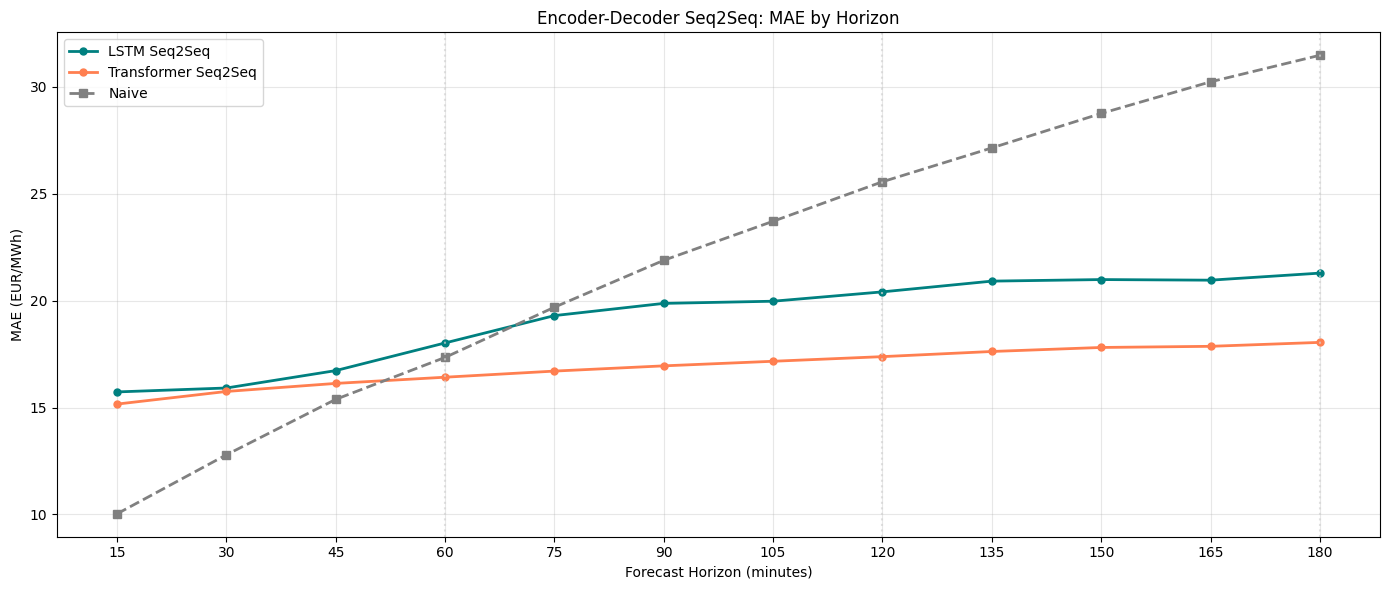

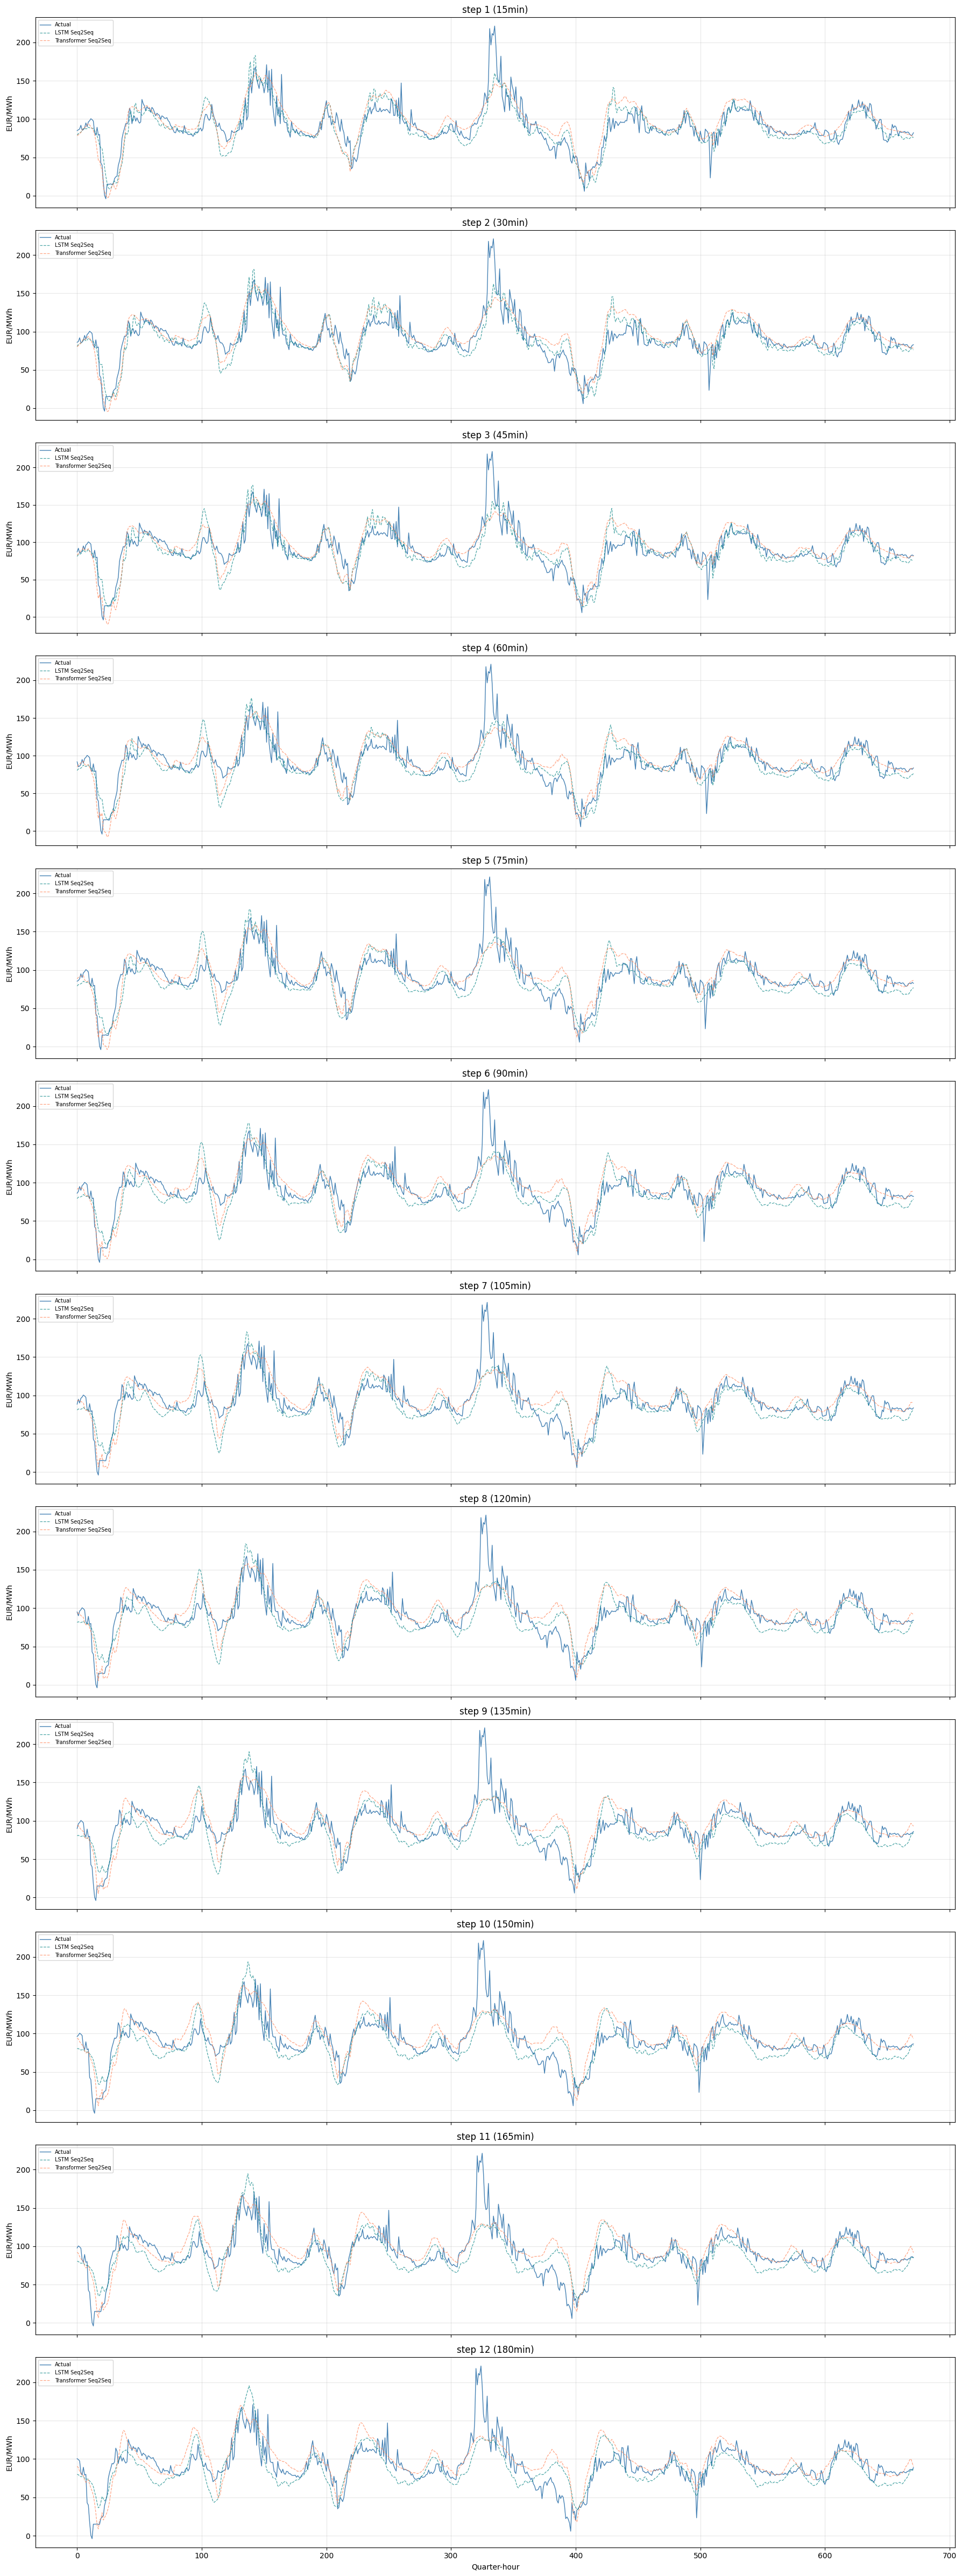

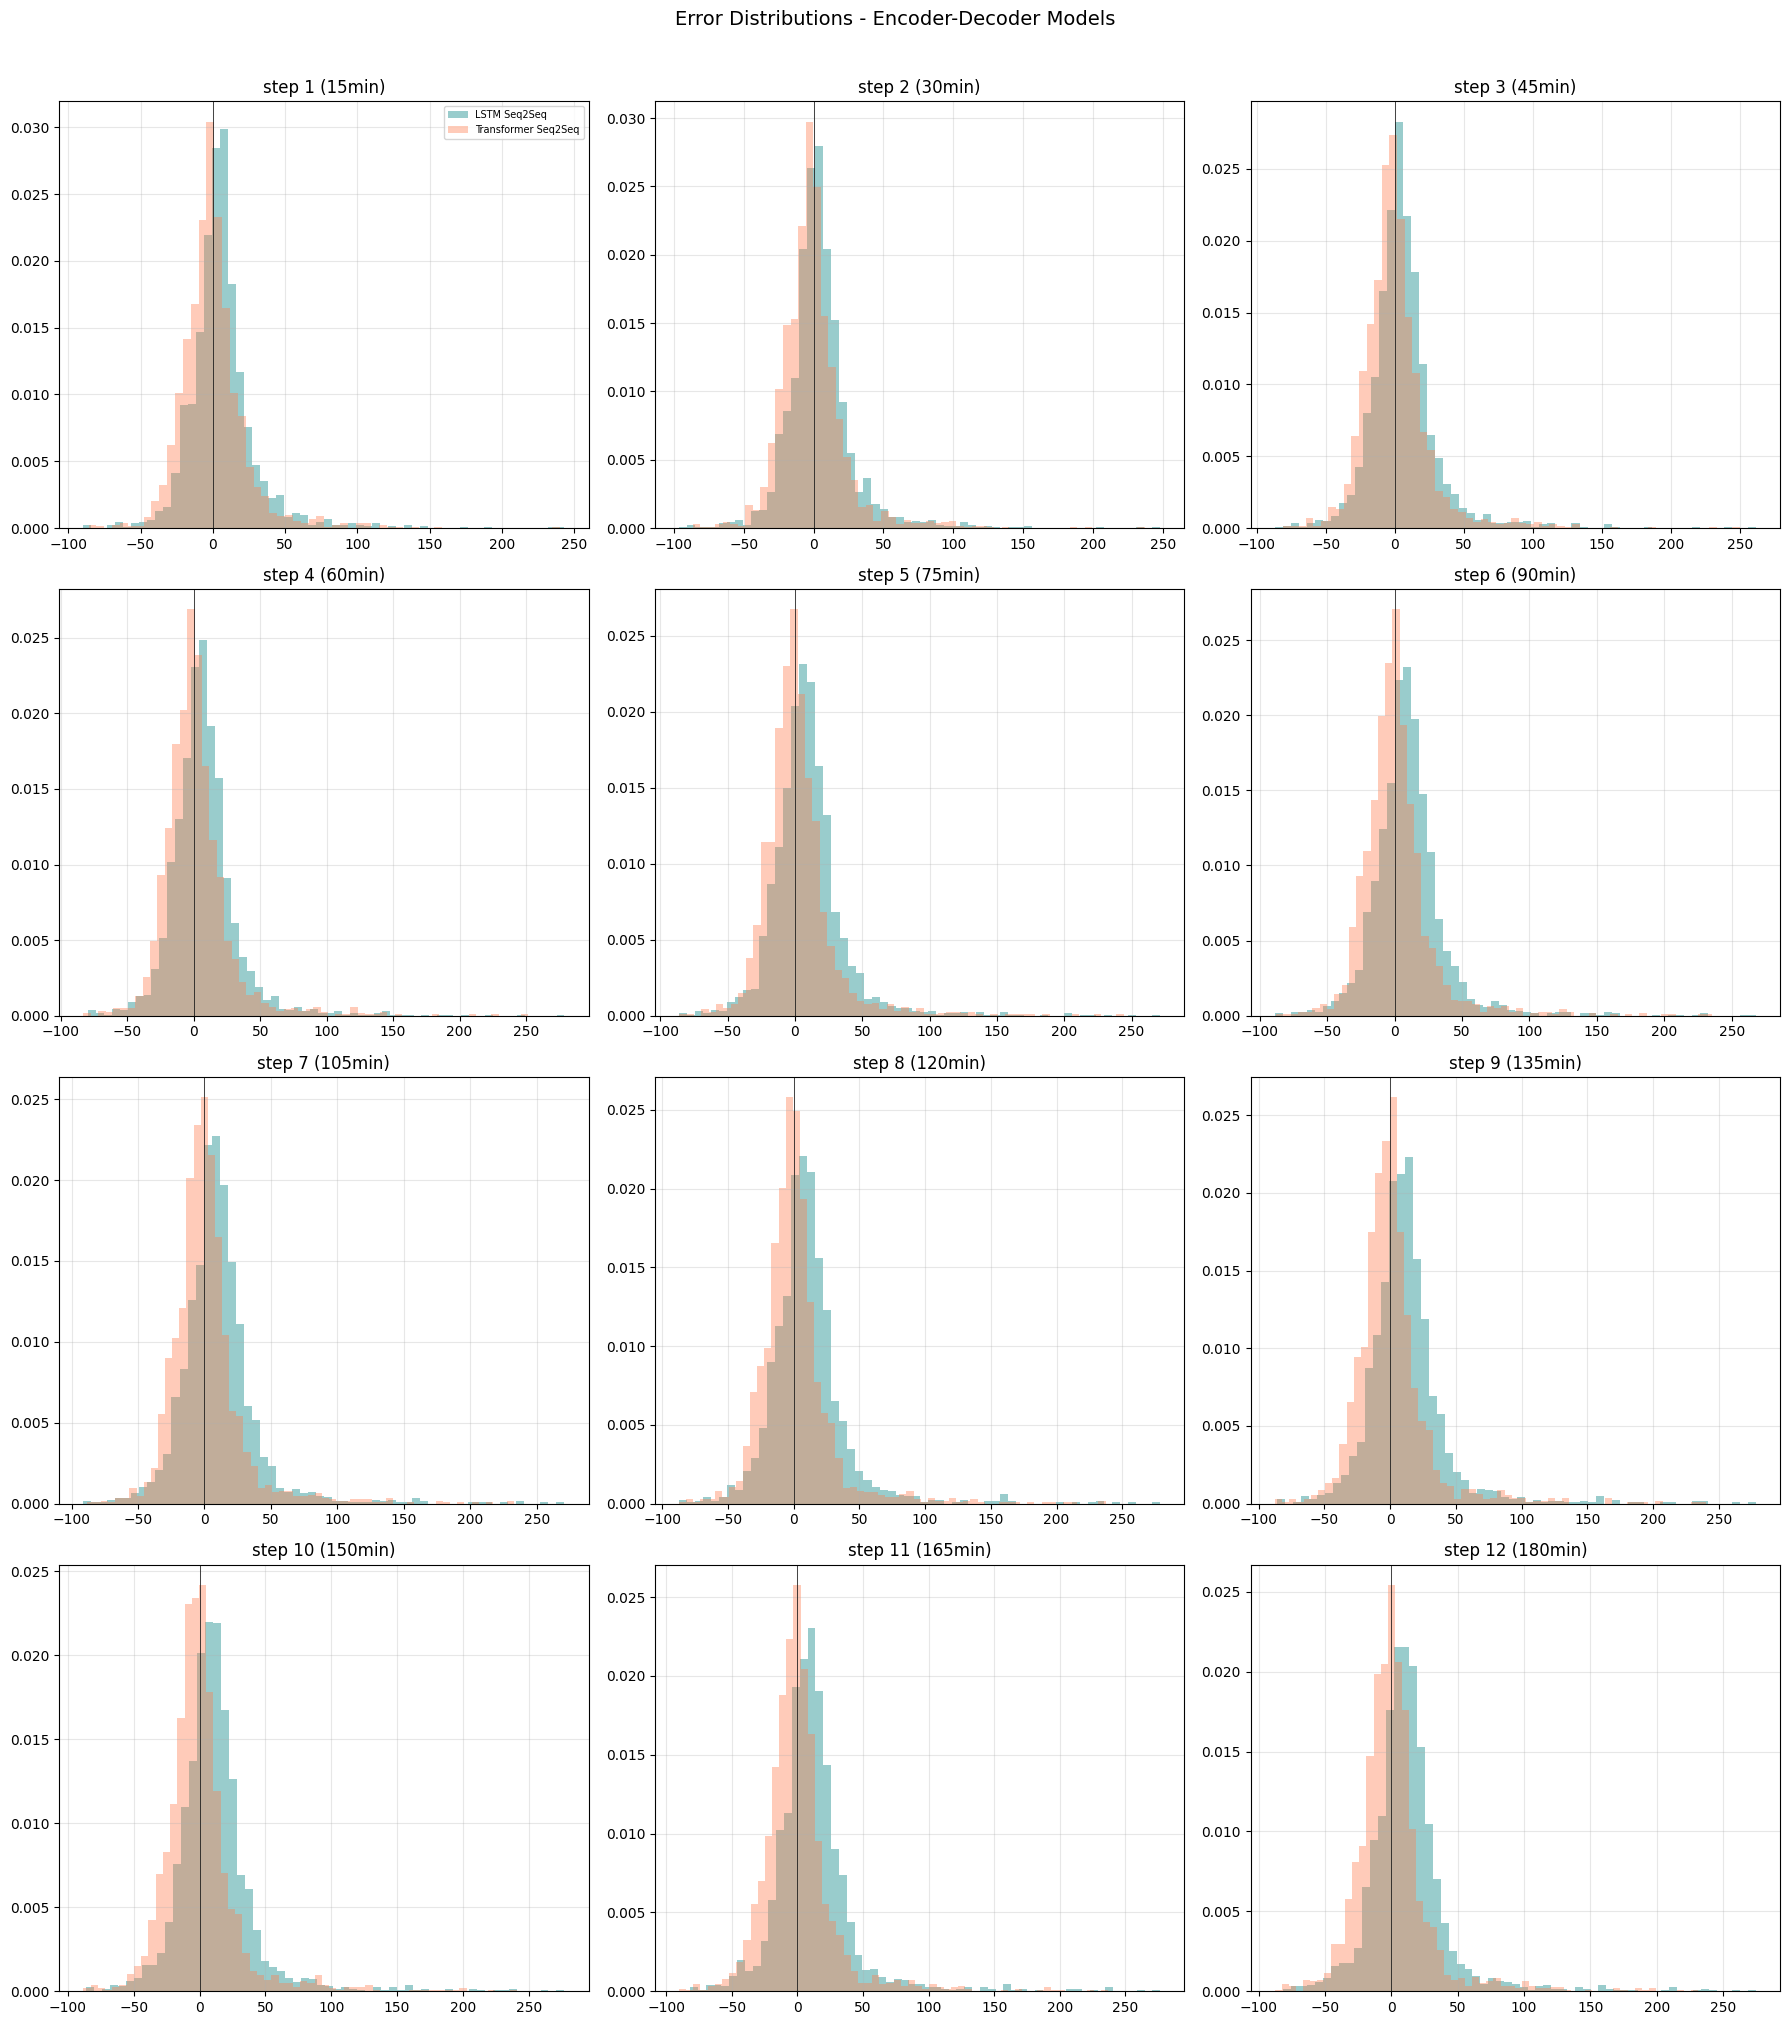

In [13]:
colors = {'LSTM Seq2Seq': 'teal', 'Transformer Seq2Seq': 'coral'}

# Error accumulation
fig, ax = plt.subplots(figsize=(14, 6))
minutes = np.arange(1, PRED_STEPS+1) * 15
for name, preds in results.items():
    maes = [mean_absolute_error(acts[:, h], preds[:, h]) for h in range(PRED_STEPS)]
    ax.plot(minutes, maes, 'o-', color=colors[name], label=name, linewidth=2, markersize=5)
naive_maes = [mean_absolute_error(acts[:, h], naive_vals) for h in range(PRED_STEPS)]
ax.plot(minutes, naive_maes, 's--', color='gray', label='Naive', linewidth=2)
for m in [60, 120, 180]: ax.axvline(m, color='lightgray', linestyle=':', alpha=0.7)
ax.set_xlabel('Forecast Horizon (minutes)'); ax.set_ylabel('MAE (EUR/MWh)')
ax.set_title('Encoder-Decoder Seq2Seq: MAE by Horizon')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xticks(minutes)
plt.tight_layout(); plt.show()

# Prediction plots - all 12 steps
N_PLOT = 96 * 7
fig, axes = plt.subplots(12, 1, figsize=(18, 48), sharex=True)
for h, ax in enumerate(axes):
    ax.plot(acts[:N_PLOT, h], color='steelblue', linewidth=1, label='Actual')
    for name, preds in results.items():
        ax.plot(preds[:N_PLOT, h], color=colors[name], linewidth=0.9, linestyle='--', alpha=0.7, label=name)
    ax.set_ylabel('EUR/MWh')
    ax.set_title(f'step {h+1} ({(h+1)*15}min)')
    ax.legend(loc='upper left', fontsize=7); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Quarter-hour')
plt.tight_layout(); plt.show()

# Error distributions
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
for h in range(PRED_STEPS):
    ax = axes[h // 3, h % 3]
    for name, preds in results.items():
        err = acts[:, h] - preds[:, h]
        ax.hist(err, bins=60, alpha=0.4, color=colors[name], label=name, density=True)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(f'step {h+1} ({(h+1)*15}min)')
    if h == 0: ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('Error Distributions - Encoder-Decoder Models', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()



## 13. Export


In [14]:
ts = df['DELIVERY_MTU'].values[split_idx:split_idx+n_test]
out = pd.DataFrame({'timestamp': ts, 'hour': pd.to_datetime(ts).hour})
for name, preds in results.items():
    for s in range(PRED_STEPS):
        out[f'{name}_step{s+1}'] = preds[:, s]
for s in range(PRED_STEPS):
    out[f'actual_step{s+1}'] = acts[:, s]
out['naive'] = naive_vals
out.to_csv('seq2seq_predictions.csv', index=False)
print(f"Exported: {out.shape}")

from google.colab import files
files.download('seq2seq_predictions.csv')



Exported: (2093, 39)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. Summary

| Model | Encoder | Decoder | Teacher Forcing | Generation |
|---|---|---|---|---|
| **LSTM Seq2Seq** | LSTM encoder | LSTM decoder with context | Annealed 1.0 to 0.1 | Autoregressive |
| **Transformer Seq2Seq** | TransformerEncoder | TransformerDecoder with causal mask + cross-attention | Annealed 1.0 to 0.1 | Autoregressive |

**Key question:** Does training a dedicated decoder with teacher forcing reduce error accumulation compared to the recursive approach (which loops a single-step model)? Compare these results with the recursive tables to find out.


In [15]:
# ============================================================
#  COMPARISON AT KEY HORIZONS: ALL 4 STRATEGIES
# ============================================================

print("=" * 80)
print("  COMPARISON AT 1h, 2h, 3h — ALL STRATEGIES (Period A)")
print("=" * 80)

# Previous results (from other notebooks)
prev = {
    'Direct 3-step': {
        'MLP':  [17.12, 17.05, 17.80], 'LSTM': [17.03, 18.10, 18.96],
        'XGB':  [15.90, 17.88, 18.98], 'TF':   [16.15, 17.48, 18.18],
        'iTF':  [15.90, 17.20, 18.14],
    },
    'Direct 12-step': {
        'MLP':  [15.84, 16.91, 18.62], 'LSTM': [16.44, 18.23, 19.30],
        'XGB':  [16.24, 18.65, 19.78], 'TF':   [15.81, 17.42, 18.27],
        'iTF':  [16.74, 17.51, 18.07],
    },
    'Recursive': {
        'MLP':  [15.55, 19.48, 23.25], 'LSTM': [16.73, 23.87, 29.43],
        'XGB':  [15.33, 19.79, 24.63], 'TF':   [14.86, 19.77, 24.57],
        'iTF':  [16.01, 21.21, 26.14],
    },
}

# Seq2Seq results from this notebook
s2s_lstm = [mean_absolute_error(acts[:, h], preds_lstm[:, h]) for h in [3, 7, 11]]
s2s_tf   = [mean_absolute_error(acts[:, h], preds_tf[:, h])   for h in [3, 7, 11]]
naive_r  = [mean_absolute_error(acts[:, h], naive_vals)        for h in [3, 7, 11]]

# Print comparison table
horizons = ['1h (step 4)', '2h (step 8)', '3h (step 12)']

for hi, h_label in enumerate(horizons):
    print(f"\n  === {h_label} ===")
    print(f"  {'Strategy':<20} {'MLP':>8} {'LSTM':>8} {'XGB':>8} {'TF':>8} {'iTF':>8}")
    print(f"  {'-'*65}")
    for strat_name, strat_data in prev.items():
        row = f"  {strat_name:<20}"
        for model in ['MLP', 'LSTM', 'XGB', 'TF', 'iTF']:
            row += f" {strat_data[model][hi]:>8.2f}"
        print(row)
    # Seq2Seq row
    row = f"  {'Enc-Dec Seq2Seq':<20}"
    row += f" {'---':>8}"  # MLP
    row += f" {s2s_lstm[hi]:>8.2f}"
    row += f" {'---':>8}"  # XGB
    row += f" {s2s_tf[hi]:>8.2f}"
    row += f" {'---':>8}"  # iTF
    print(row)
    print(f"  {'Naive':<20} {naive_r[hi]:>8.2f}")

# Best per strategy summary
print(f"\n{'=' * 80}")
print(f"  BEST MODEL PER STRATEGY AT EACH HORIZON")
print(f"{'=' * 80}")
print(f"  {'Strategy':<20} {'1h':>12} {'2h':>12} {'3h':>12}")
print(f"  {'-'*58}")
print(f"  {'Direct 3-step':<20} {'15.90':>12} {'17.05':>12} {'17.80':>12}")
print(f"  {'Direct 12-step':<20} {'15.81':>12} {'16.91':>12} {'18.07':>12}")
print(f"  {'Recursive':<20} {'14.86':>12} {'19.48':>12} {'23.25':>12}")
print(f"  {'Seq2Seq LSTM':<20} {s2s_lstm[0]:>12.2f} {s2s_lstm[1]:>12.2f} {s2s_lstm[2]:>12.2f}")
print(f"  {'Seq2Seq TF':<20} {s2s_tf[0]:>12.2f} {s2s_tf[1]:>12.2f} {s2s_tf[2]:>12.2f}")
print(f"  {'Naive':<20} {naive_r[0]:>12.2f} {naive_r[1]:>12.2f} {naive_r[2]:>12.2f}")

print(f"\n  KEY FINDINGS:")
print(f"  - Transformer Seq2Seq at 3h: {s2s_tf[2]:.2f} vs Recursive best: 23.25 vs Direct best: 17.80")
print(f"  - Teacher forcing reduced LSTM error accumulation: {s2s_lstm[2]:.2f} vs Recursive LSTM: 29.43")
print(f"  - Transformer Seq2Seq has the flattest error profile of any sequential method")

  COMPARISON AT 1h, 2h, 3h — ALL STRATEGIES (Period A)

  === 1h (step 4) ===
  Strategy                  MLP     LSTM      XGB       TF      iTF
  -----------------------------------------------------------------
  Direct 3-step           17.12    17.03    15.90    16.15    15.90
  Direct 12-step          15.84    16.44    16.24    15.81    16.74
  Recursive               15.55    16.73    15.33    14.86    16.01
  Enc-Dec Seq2Seq           ---    18.02      ---    16.42      ---
  Naive                   17.34

  === 2h (step 8) ===
  Strategy                  MLP     LSTM      XGB       TF      iTF
  -----------------------------------------------------------------
  Direct 3-step           17.05    18.10    17.88    17.48    17.20
  Direct 12-step          16.91    18.23    18.65    17.42    17.51
  Recursive               19.48    23.87    19.79    19.77    21.21
  Enc-Dec Seq2Seq           ---    20.41      ---    17.38      ---
  Naive                   25.56

  === 3h (step 12)

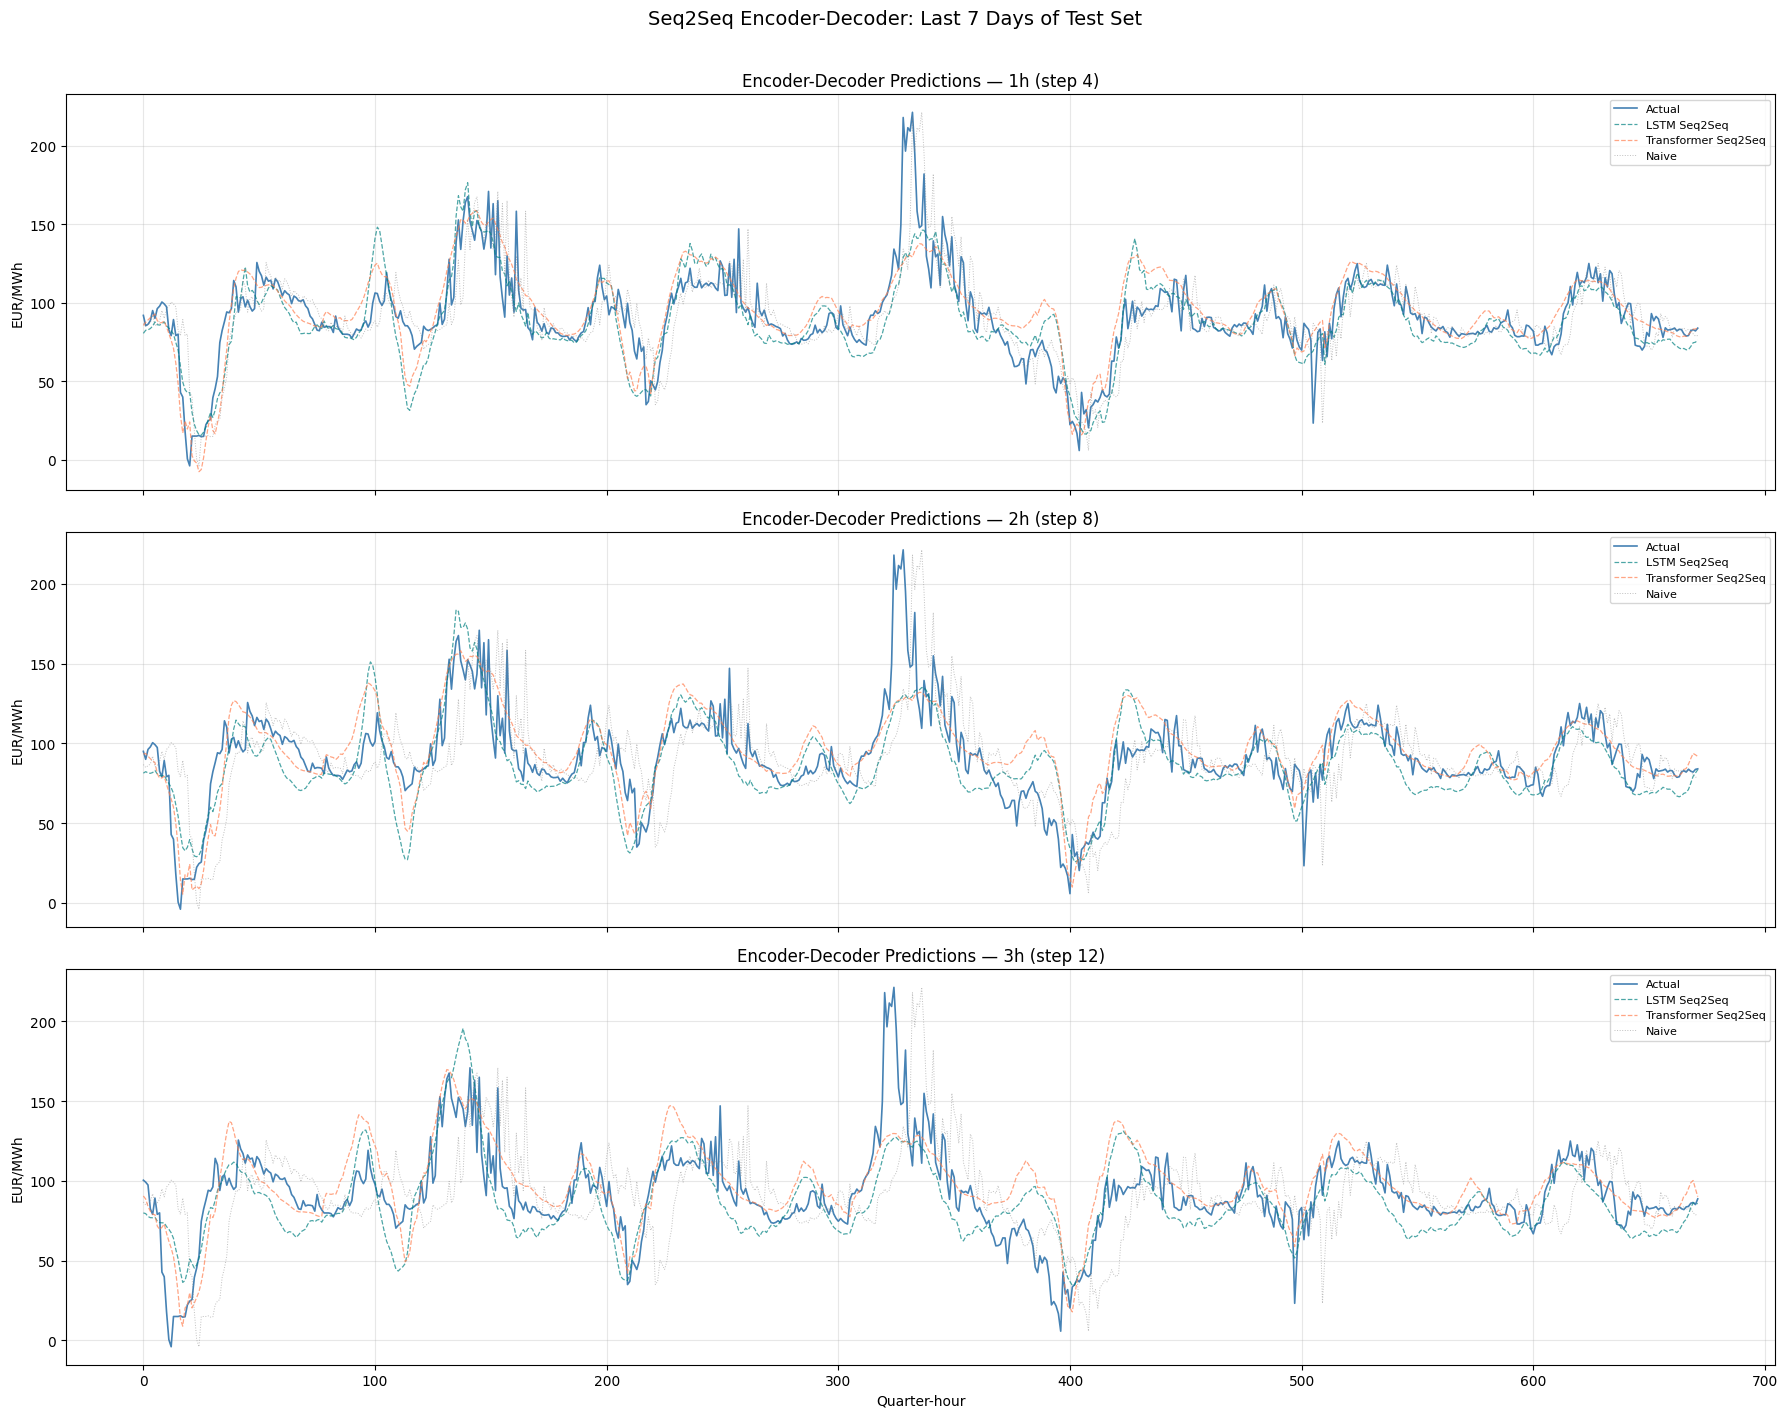


  ENCODER-DECODER RESULTS AT KEY HORIZONS
  Model                        1h       2h       3h
  ------------------------------------------------
  LSTM Seq2Seq              18.02    20.41    21.28
  Transformer Seq2Seq       16.42    17.38    18.04
  Naive                     17.34    25.56    31.47


In [17]:
# ============================================================
#  PREDICTION PLOTS AT KEY HORIZONS: 1h, 2h, 3h
# ============================================================

N_PLOT = 96 * 7  # 7 days
key_steps = [(3, '1h (step 4)'), (7, '2h (step 8)'), (11, '3h (step 12)')]
colors = {'LSTM Seq2Seq': 'teal', 'Transformer Seq2Seq': 'coral'}

# --- Actual vs Predicted at 1h, 2h, 3h ---
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)
for ax, (h, label) in zip(axes, key_steps):
    ax.plot(acts[:N_PLOT, h], color='steelblue', linewidth=1.2, label='Actual')
    ax.plot(preds_lstm[:N_PLOT, h], color='teal', linewidth=0.9, linestyle='--', alpha=0.7, label='LSTM Seq2Seq')
    ax.plot(preds_tf[:N_PLOT, h], color='coral', linewidth=0.9, linestyle='--', alpha=0.7, label='Transformer Seq2Seq')
    ax.plot(naive_vals[:N_PLOT], color='gray', linewidth=0.7, linestyle=':', alpha=0.5, label='Naive')
    ax.set_ylabel('EUR/MWh')
    ax.set_title(f'Encoder-Decoder Predictions — {label}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Quarter-hour')
plt.suptitle('Seq2Seq Encoder-Decoder: Last 7 Days of Test Set', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('seq2seq_predictions_1h_2h_3h.png', dpi=150, bbox_inches='tight')
plt.show()

# --- MAE summary at key horizons ---
print("\n  ENCODER-DECODER RESULTS AT KEY HORIZONS")
print(f"  {'Model':<22} {'1h':>8} {'2h':>8} {'3h':>8}")
print(f"  {'-'*48}")
for name, preds in results.items():
    maes = [mean_absolute_error(acts[:, h], preds[:, h]) for h in [3, 7, 11]]
    print(f"  {name:<22} {maes[0]:>8.2f} {maes[1]:>8.2f} {maes[2]:>8.2f}")
naive_maes = [mean_absolute_error(acts[:, h], naive_vals) for h in [3, 7, 11]]
print(f"  {'Naive':<22} {naive_maes[0]:>8.2f} {naive_maes[1]:>8.2f} {naive_maes[2]:>8.2f}")

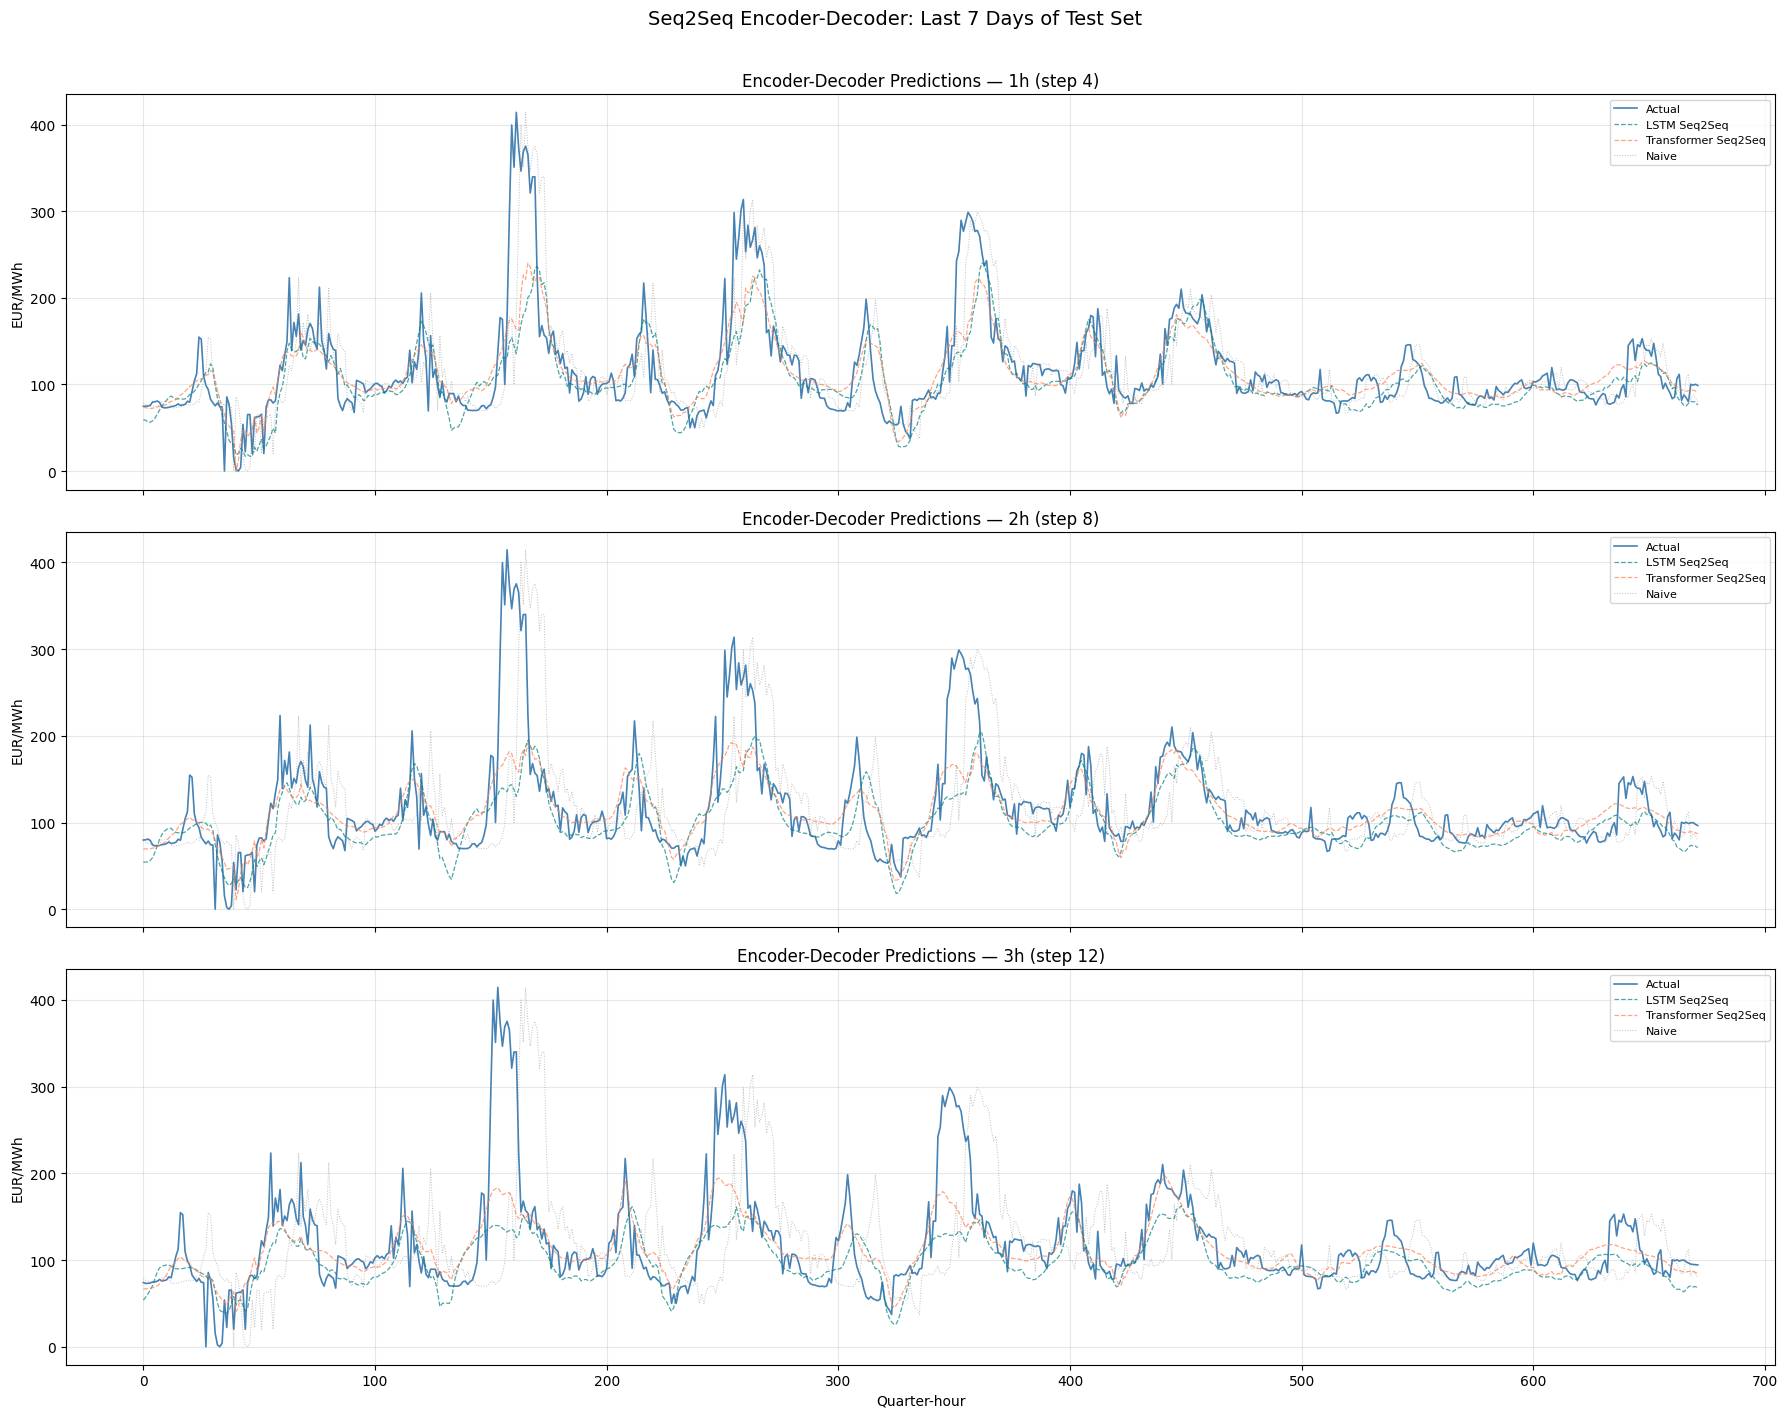

In [18]:
N_PLOT = 96 * 7  # last 7 days

# --- Actual vs Predicted at 1h, 2h, 3h (LAST 7 days) ---
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)
for ax, (h, label) in zip(axes, key_steps):
    ax.plot(acts[-N_PLOT:, h], color='steelblue', linewidth=1.2, label='Actual')
    ax.plot(preds_lstm[-N_PLOT:, h], color='teal', linewidth=0.9, linestyle='--', alpha=0.7, label='LSTM Seq2Seq')
    ax.plot(preds_tf[-N_PLOT:, h], color='coral', linewidth=0.9, linestyle='--', alpha=0.7, label='Transformer Seq2Seq')
    ax.plot(naive_vals[-N_PLOT:], color='gray', linewidth=0.7, linestyle=':', alpha=0.5, label='Naive')
    ax.set_ylabel('EUR/MWh')
    ax.set_title(f'Encoder-Decoder Predictions — {label}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Quarter-hour')
plt.suptitle('Seq2Seq Encoder-Decoder: Last 7 Days of Test Set', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('seq2seq_predictions_last7days.png', dpi=150, bbox_inches='tight')
plt.show()

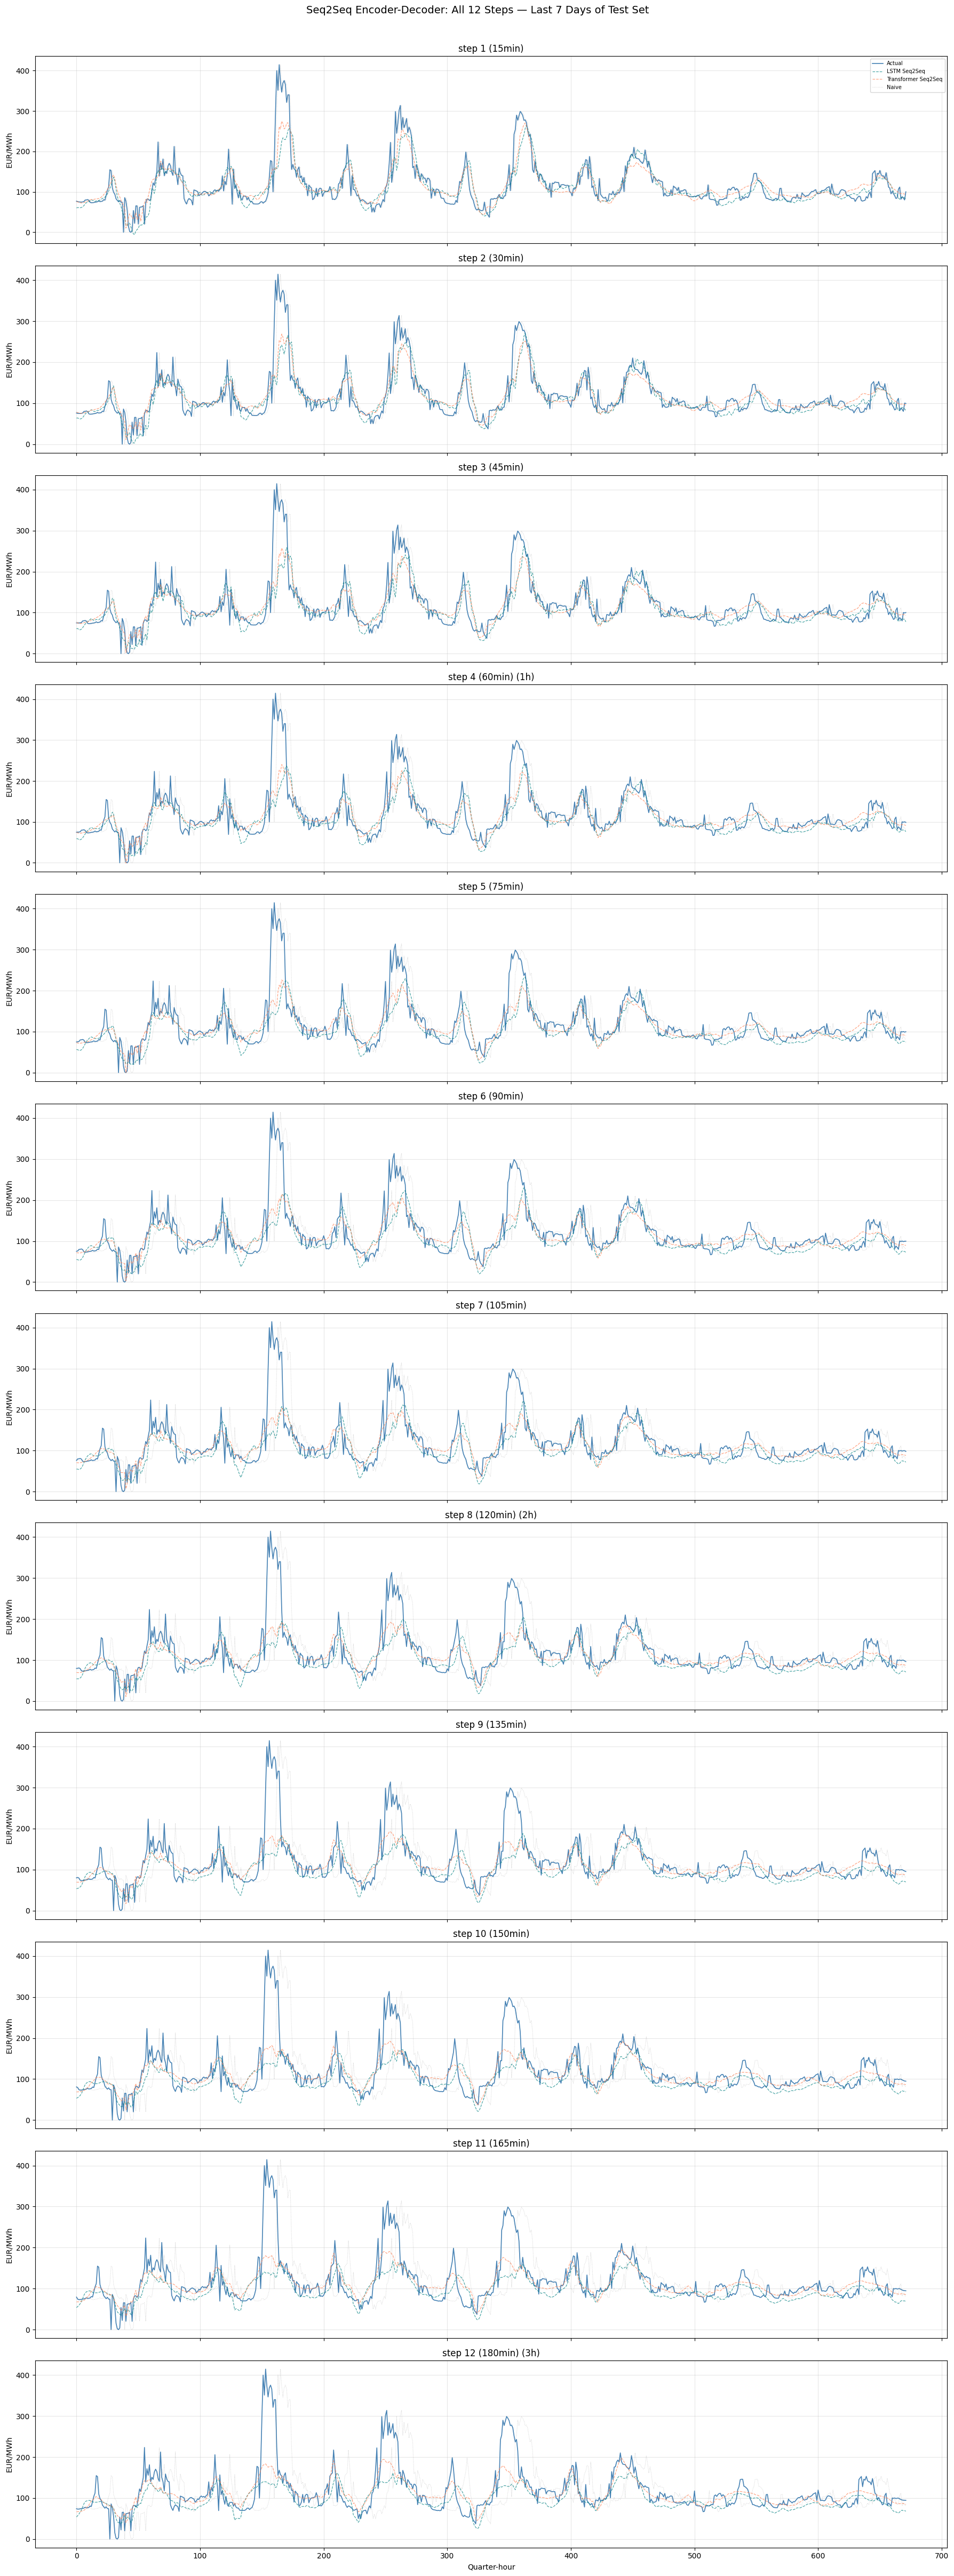

In [20]:
# --- All 12 steps, last 7 days of test set ---
N_PLOT = 96 * 7

fig, axes = plt.subplots(12, 1, figsize=(18, 48), sharex=True)
for h, ax in enumerate(axes):
    ax.plot(acts[-N_PLOT:, h], color='steelblue', linewidth=1.2, label='Actual')
    ax.plot(preds_lstm[-N_PLOT:, h], color='teal', linewidth=0.9, linestyle='--', alpha=0.7, label='LSTM Seq2Seq')
    ax.plot(preds_tf[-N_PLOT:, h], color='coral', linewidth=0.9, linestyle='--', alpha=0.7, label='Transformer Seq2Seq')
    ax.plot(naive_vals[-N_PLOT:], color='gray', linewidth=0.7, linestyle=':', alpha=0.4, label='Naive')
    ax.set_ylabel('EUR/MWh')
    h_label = {4: ' (1h)', 8: ' (2h)', 12: ' (3h)'}.get(h+1, '')
    ax.set_title(f'step {h+1} ({(h+1)*15}min){h_label}')
    if h == 0:
        ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Quarter-hour')
plt.suptitle('Seq2Seq Encoder-Decoder: All 12 Steps — Last 7 Days of Test Set', fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig('seq2seq_all12steps_last7days.png', dpi=150, bbox_inches='tight')
plt.show()

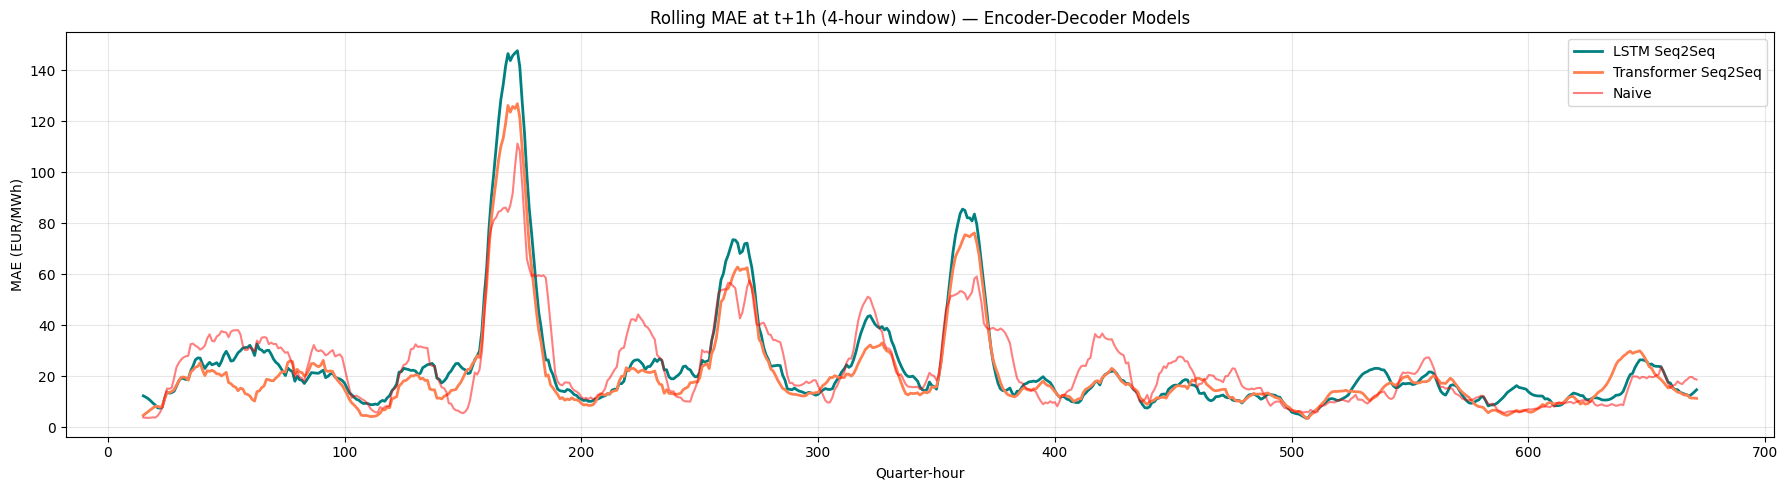

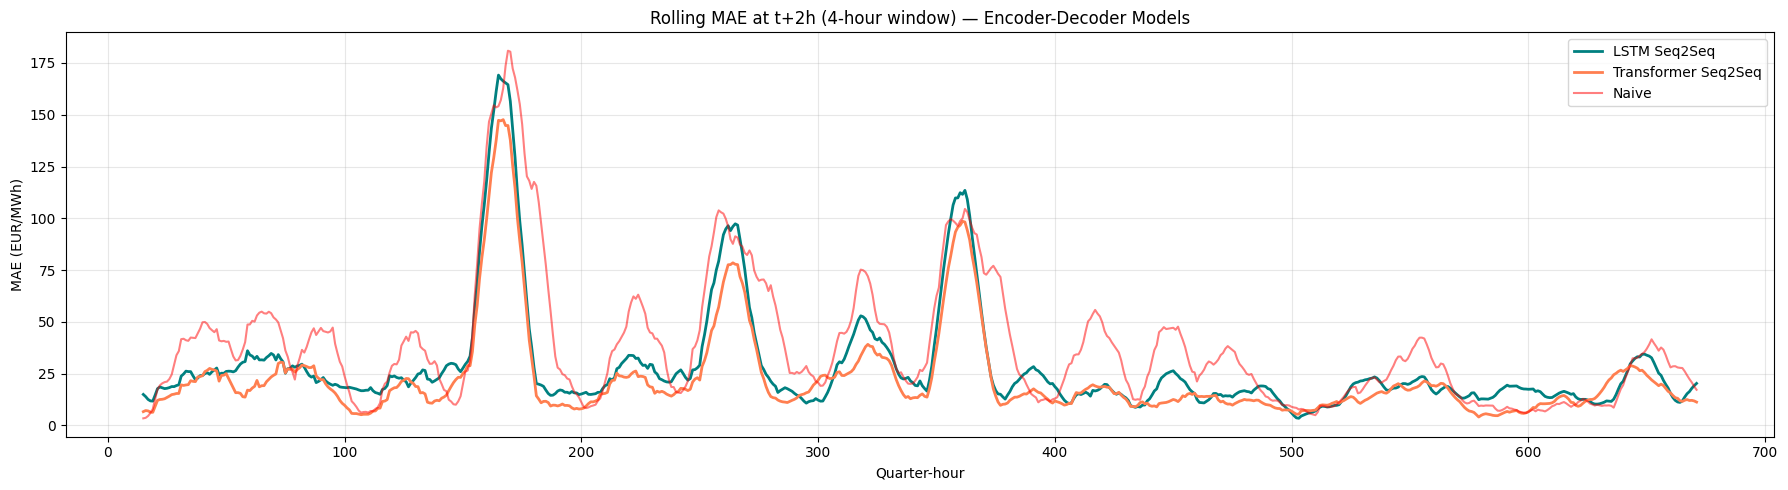

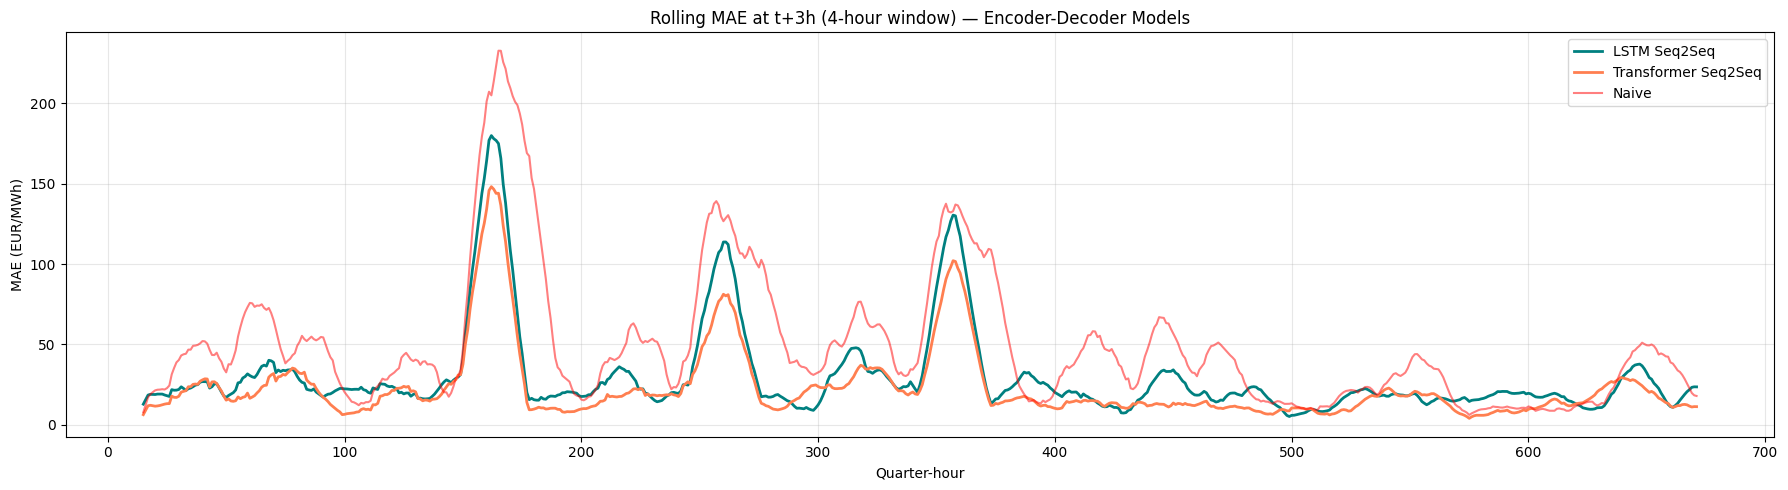

In [22]:
# Rolling MAE at t+4 (1h) — last 7 days
fig, ax = plt.subplots(figsize=(18, 5))
w = 16
h_idx = 3  # step 4 = 1h
N_PLOT = 96 * 7

for name, preds in results.items():
    err = np.abs(acts[-N_PLOT:, h_idx] - preds[-N_PLOT:, h_idx])
    ax.plot(pd.Series(err).rolling(w).mean(), color=colors[name], linewidth=2, label=name)
err_n = np.abs(acts[-N_PLOT:, h_idx] - naive_vals[-N_PLOT:])
ax.plot(pd.Series(err_n).rolling(w).mean(), color='red', linewidth=1.5, alpha=0.5, label='Naive')
ax.set_title('Rolling MAE at t+1h (4-hour window) — Encoder-Decoder Models')
ax.set_ylabel('MAE (EUR/MWh)')
ax.set_xlabel('Quarter-hour'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Rolling MAE at t+8 (2h)
fig, ax = plt.subplots(figsize=(18, 5))
h_idx = 7
for name, preds in results.items():
    err = np.abs(acts[-N_PLOT:, h_idx] - preds[-N_PLOT:, h_idx])
    ax.plot(pd.Series(err).rolling(w).mean(), color=colors[name], linewidth=2, label=name)
err_n = np.abs(acts[-N_PLOT:, h_idx] - naive_vals[-N_PLOT:])
ax.plot(pd.Series(err_n).rolling(w).mean(), color='red', linewidth=1.5, alpha=0.5, label='Naive')
ax.set_title('Rolling MAE at t+2h (4-hour window) — Encoder-Decoder Models')
ax.set_ylabel('MAE (EUR/MWh)')
ax.set_xlabel('Quarter-hour'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Rolling MAE at t+12 (3h)
fig, ax = plt.subplots(figsize=(18, 5))
h_idx = 11
for name, preds in results.items():
    err = np.abs(acts[-N_PLOT:, h_idx] - preds[-N_PLOT:, h_idx])
    ax.plot(pd.Series(err).rolling(w).mean(), color=colors[name], linewidth=2, label=name)
err_n = np.abs(acts[-N_PLOT:, h_idx] - naive_vals[-N_PLOT:])
ax.plot(pd.Series(err_n).rolling(w).mean(), color='red', linewidth=1.5, alpha=0.5, label='Naive')
ax.set_title('Rolling MAE at t+3h (4-hour window) — Encoder-Decoder Models')
ax.set_ylabel('MAE (EUR/MWh)')
ax.set_xlabel('Quarter-hour'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [23]:
# ============================================================
#  FINAL: ALL 4 STRATEGIES SIDE BY SIDE AT 1h, 2h, 3h
# ============================================================

s2s_lstm_mae = [mean_absolute_error(acts[:, h], preds_lstm[:, h]) for h in [3, 7, 11]]
s2s_tf_mae   = [mean_absolute_error(acts[:, h], preds_tf[:, h])   for h in [3, 7, 11]]
naive_mae    = [mean_absolute_error(acts[:, h], naive_vals)        for h in [3, 7, 11]]

print("=" * 70)
print("  ALL 4 STRATEGIES - MAE AT KEY HORIZONS (Period A)")
print("=" * 70)
print(f"  {'Strategy + Model':<28} {'1h':>8} {'2h':>8} {'3h':>8}")
print(f"  {'-'*55}")
print(f"  {'Direct 3-step MLP':<28} {'17.12':>8} {'17.05':>8} {'17.80':>8}")
print(f"  {'Direct 3-step iTransformer':<28} {'15.90':>8} {'17.20':>8} {'18.14':>8}")
print(f"  {'Direct 3-step Transformer':<28} {'16.15':>8} {'17.48':>8} {'18.18':>8}")
print(f"  {'Direct 3-step XGBoost':<28} {'15.90':>8} {'17.88':>8} {'18.98':>8}")
print(f"  {'-'*55}")
print(f"  {'Direct 12-step MLP':<28} {'15.84':>8} {'16.91':>8} {'18.62':>8}")
print(f"  {'Direct 12-step Transformer':<28} {'15.81':>8} {'17.42':>8} {'18.27':>8}")
print(f"  {'Direct 12-step iTransformer':<28} {'16.74':>8} {'17.51':>8} {'18.07':>8}")
print(f"  {'-'*55}")
print(f"  {'Recursive MLP':<28} {'15.55':>8} {'19.48':>8} {'23.25':>8}")
print(f"  {'Recursive Transformer':<28} {'14.86':>8} {'19.77':>8} {'24.57':>8}")
print(f"  {'Recursive XGBoost':<28} {'15.33':>8} {'19.79':>8} {'24.63':>8}")
print(f"  {'-'*55}")
print(f"  {'Seq2Seq LSTM':<28} {s2s_lstm_mae[0]:>8.2f} {s2s_lstm_mae[1]:>8.2f} {s2s_lstm_mae[2]:>8.2f}")
print(f"  {'Seq2Seq Transformer':<28} {s2s_tf_mae[0]:>8.2f} {s2s_tf_mae[1]:>8.2f} {s2s_tf_mae[2]:>8.2f}")
print(f"  {'-'*55}")
print(f"  {'Naive':<28} {naive_mae[0]:>8.2f} {naive_mae[1]:>8.2f} {naive_mae[2]:>8.2f}")

print(f"\n  KEY TAKEAWAYS:")
print(f"  Best 1h:  Recursive TF (14.86)")
print(f"  Best 2h:  Direct 12-step MLP (16.91)")
print(f"  Best 3h:  Direct 3-step MLP (17.80)")
print(f"  Seq2Seq TF at 3h: {s2s_tf_mae[2]:.2f} (close to direct, much better than recursive)")
print(f"  Seq2Seq LSTM at 3h: {s2s_lstm_mae[2]:.2f} (vs recursive LSTM 29.43 = teacher forcing saved 8 EUR)")

  ALL 4 STRATEGIES - MAE AT KEY HORIZONS (Period A)
  Strategy + Model                   1h       2h       3h
  -------------------------------------------------------
  Direct 3-step MLP               17.12    17.05    17.80
  Direct 3-step iTransformer      15.90    17.20    18.14
  Direct 3-step Transformer       16.15    17.48    18.18
  Direct 3-step XGBoost           15.90    17.88    18.98
  -------------------------------------------------------
  Direct 12-step MLP              15.84    16.91    18.62
  Direct 12-step Transformer      15.81    17.42    18.27
  Direct 12-step iTransformer     16.74    17.51    18.07
  -------------------------------------------------------
  Recursive MLP                   15.55    19.48    23.25
  Recursive Transformer           14.86    19.77    24.57
  Recursive XGBoost               15.33    19.79    24.63
  -------------------------------------------------------
  Seq2Seq LSTM                    18.02    20.41    21.28
  Seq2Seq Transforme